In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import copy as cp
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import zeus
import toml
from types import SimpleNamespace

import alfred.KSZ
import alfred.surveys
import alfred.utils as utils

from catwoman.shelter import Cat
from alfred.emulator import kemu
from alfred.parameters import *
from alfred.astrofit import *


parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

# Introduction

This notebook contains all the code necessary to reproduce the plots of the paper

In [6]:
spectra_path = 'ps_ee'

In [7]:
from scipy.integrate import cumulative_trapezoid

def xe2tau_plot(z):
        """
        Computes redshift evolution of the model's optical depth. This one is reversed for plotting purposes

        Parameters
        ----------
            z: (array of) float(s)
                Redshift range used to compute the optical depth.
        """
        cos = cosmology.FlatLambdaCDM(
            H0=ksz.h * 100, Tcmb0=ksz.T_cmb, Ob0=ksz.Ob_0, Om0=ksz.Om_0
        )
        z = np.sort(z)
        xe = np.sort(ksz.xe(z))[::-1]

        integ = constants.c.value * constants.sigma_T.value * ksz.nh * xe \
            / cos.H(z).si.value * (1+z)**2
        tofz = cumulative_trapezoid(integ, z, initial=0)

        return tofz

In [8]:
# fig, ax = plt.subplots(sharex=True, figsize=(7,5))
# fig.subplots_adjust(hspace=.00)

# norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
# cmap = plt.get_cmap('viridis')

# for i, sn in enumerate(df.index):
#     if i % 1000 == 0:
#         # continue
#         print(f"Completed {i+1}/{len(df)}...")


#     sim = Cat(sn, skip_early=True,
#                         base_dir=base_dir,
#                         path_spectra=spectra_path,
#                         LoReLi_format=True,
#                         verbose=False)
    
#     ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
#                 helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
#                 xemax=.97)
    
#     color = cmap(norm(df.loc[sn]['fesc'])) 
#     # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
#     #     color = 'darkblue'


#     ax.semilogy(z3, ksz.xe(z3), color=color, alpha=.25)
#     # ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)
    
# ax.set_xlim(3.2,14.3)

# ax.set_xlabel(rf"$z$", fontsize=16)
# ax.set_ylabel(rf"$x_e(z)$", fontsize=16)

# fig.savefig('xe.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300, rasterized=True)

In [11]:
xe_histories['14858']

{'z': array([15.122 , 14.843 , 14.577 , 14.321 , 14.075 , 13.839 , 13.612 ,
        13.393 , 13.182 , 12.979 , 12.783 , 12.594 , 12.411 , 12.234 ,
        12.063 , 11.898 , 11.737 , 11.581 , 11.43  , 11.284 , 11.142 ,
        11.003 , 10.869 , 10.738 , 10.611 , 10.487 , 10.367 , 10.249 ,
        10.135 , 10.023 ,  9.9147,  9.8085,  9.7049,  9.6037,  9.5048,
         9.4083,  9.3139,  9.2217,  9.1314,  9.0432,  8.9568,  8.8722,
         8.7895,  8.7084,  8.629 ,  8.5512,  8.4749,  8.4002,  8.3269,
         8.255 ,  8.1845,  8.1153,  8.0474,  7.9807,  7.9153,  7.851 ,
         7.7879,  7.7259,  7.6649,  7.6051,  7.5462,  7.4883,  7.4314,
         7.3755,  7.3204,  7.2663,  7.213 ,  7.1606,  7.109 ,  7.0582,
         7.0082,  6.9589,  6.9104,  6.8627,  6.8156,  6.7693,  6.7236,
         6.6786,  6.6342,  6.5905,  6.5474,  6.5049,  6.463 ,  6.4216,
         6.3809,  6.3406,  6.301 ,  6.2618,  6.2232,  6.1851,  6.1475,
         6.1103,  6.0737,  6.0375,  6.0017,  5.9665,  5.9316,  5.8972,
 

In [16]:
print(matplotlib.__version__)

3.10.3


Completed 1001/6797...
Completed 3001/6797...
Completed 4001/6797...
Completed 5001/6797...
Completed 6001/6797...
Completed 8001/6797...


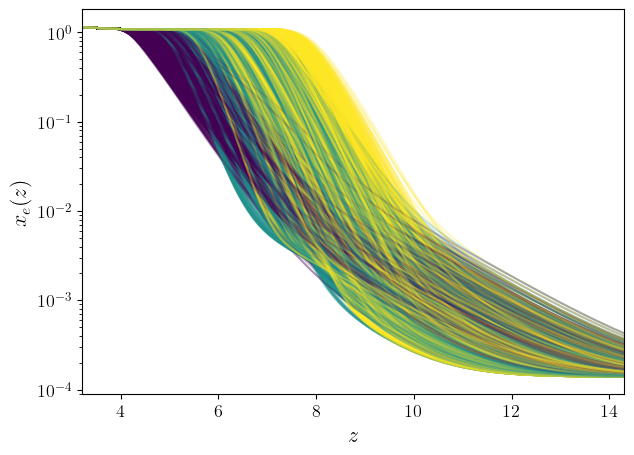

In [18]:
fig, ax = plt.subplots(sharex=True, figsize=(7,5))
fig.subplots_adjust(hspace=.00)

norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis')

for i, sn in enumerate(xe_histories):
    if sn not in df.index.to_list():
        continue
    if i % 1000 == 0:
        # continue
        print(f"Completed {i+1}/{len(df)}...")


    z_data = xe_histories[sn]['z']
    xe_data = xe_histories[sn]['xe']
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'

    ax.semilogy(z3, utils.xe(z3, z_data, xe_data), color=color, alpha=.25)
    # ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)
    
ax.set_xlim(3.2,14.3)

ax.set_xlabel(rf"$z$", fontsize=16)
ax.set_ylabel(rf"$x_e(z)$", fontsize=16)

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('xe.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
fig, ax = plt.subplots(2,1, sharex=True, figsize=(5,7))
fig.subplots_adjust(hspace=.00)


norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis_r')

ax[1].axhspan(Planck - Planck_err, Planck + Planck_err, color='lightpink', alpha=.1)
ax[1].axhspan(Planck - 2 * Planck_err, Planck + 2 * Planck_err, color='lightpink', alpha=.1)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f"Completed {i+1}/{len(df)}...")

    sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        LoReLi_format=True,
                        verbose=False)
    
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                xemax=.97)
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax[0].plot(z3, ksz.xe(z3), color=color, alpha=.25)
    ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)

ax[0].set_ylabel(rf"$x_e(z)$", fontsize=16)

ax[1].set_xlabel(rf"$z$", fontsize=16)
ax[1].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)

ax[1].set_xlim(0,12)
ax[1].set_ylim(0,.068)

fig.savefig('xe_and_tau.png')

In [20]:
# priors = [(df[p].to_numpy().min(), df[p].to_numpy().max()) for p in df.columns]

norms = []
for p in priors:
    vmin = p[0]
    vmax = p[1]

    n = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    norms.append(n)

cmap = plt.get_cmap('viridis')

In [ ]:
fig, ax = plt.subplots(1,6, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0)

import alfred.utils as utils

mob = []
tspecs_mob  = np.zeros((len(validation_sims), len(ells[indices])))
especs_mob = np.zeros_like(tspecs_mob)

for i in range(5):
    print(f"Now on {i} run...")
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

    tspecs  = np.zeros((len(validation_sims), len(ells[indices])))
    especs = np.zeros_like(tspecs)

    for si, sn in enumerate(validation_sims):
        # if si % 100 != 0:
        #     continue
        tspec = utils.spectra(sn)[indices]
        espec = emulator.kemu(df.loc[sn].to_numpy(), **emu)
        residual =  espec - tspec

        tspecs[si] = tspec
        especs[si] = espec

        if sn in bad:
            color = 'tomato'
        elif sn in good:
            color = 'navy'

        l = ax[i].plot(ells[indices], residual, color=color, alpha=.1)

        mob.append(emu)

print(f"On validation mob")
for si, sn in enumerate(validation_sims):
    if si % 1000 == 0:
        print(f"On i={si} sim...")
    #     continue
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)
    residual =  espec - tspec

    tspecs_mob[si] = tspec
    especs_mob[si] = espec

    if sn in bad:
        color = 'tomato'
    elif sn in good:
        color = 'navy'

    # print(residual)

    l = ax[-1].plot(ells[indices], residual, color=color, alpha=.1)
    
    # if lowbias[i]:
    #     color = 'navy'
    # elif not lowbias[i]:
    #     color = 'tomato'
    # l =ax[0].plot(ells[indices], tspec, color='navy', alpha=.1)
    # l =ax[0].plot(ells[indices], espec, color='tomato', alpha=.1)
ax[0].set_ylim(-.1,.1)
    

On 0th sim
On 1000th sim
On 2000th sim
13925
0.87817
On 3000th sim
On 4000th sim
On 5000th sim
On 6000th sim


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_2024/3016379786.py:61: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


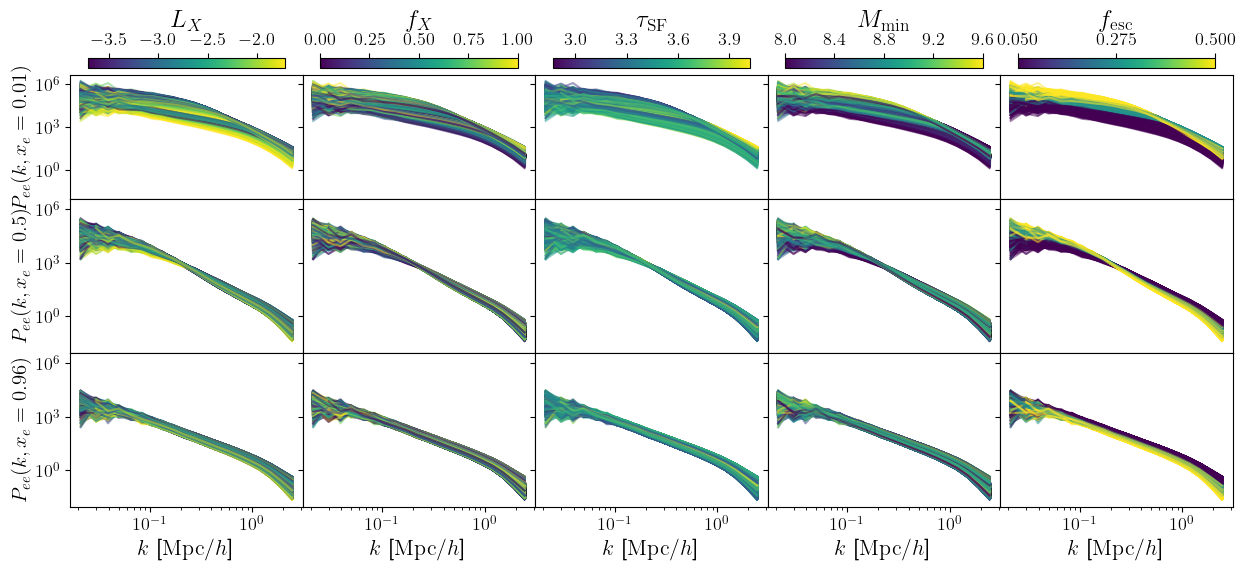

In [21]:
from scipy.interpolate import interp1d

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 5, figsize=(15,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
        # continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn]):
            color = cmap(norms[pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

ax = axes[0]
for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"$P_{{ee}}(k, x_{{e}}={xei})$", fontsize=15)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}$/$h$]', fontsize=16) for a in axes[-1]]

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

$L_X$
$f_X$
$\tau_{\mathrm{SF}}$
$M_{\mathrm{min}}$
$f_{\mathrm{esc}}$


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_2024/903522612.py:52: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


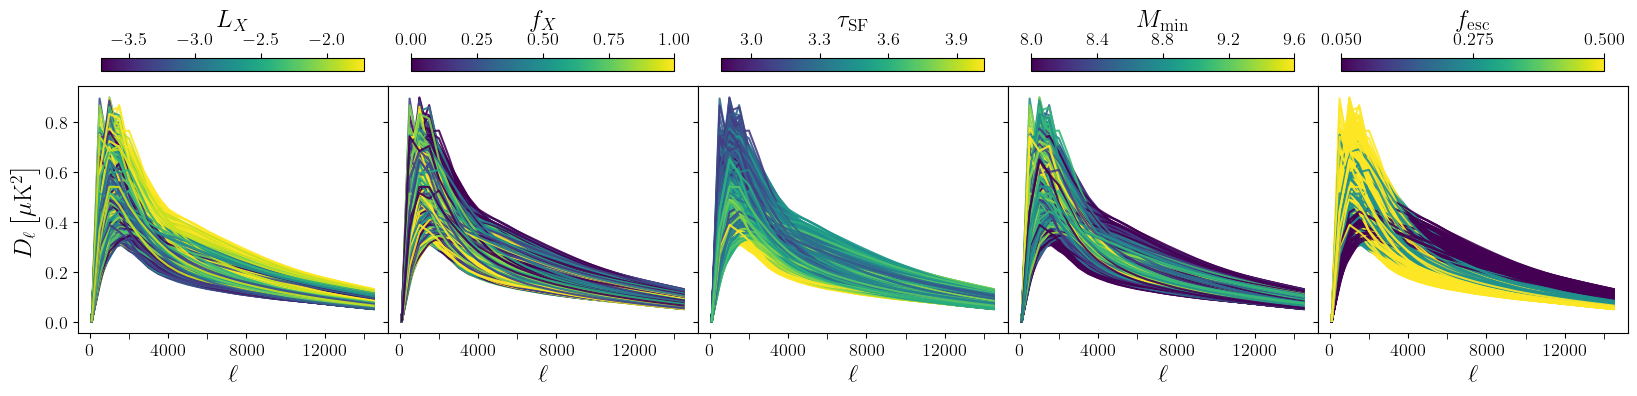

In [22]:
fig, ax = plt.subplots(1,5, sharex=True, sharey=True, figsize=(20,4))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.9)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[i])
    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=18)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=10)

ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=18)

for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

# Add minor ticks to x-axis
for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

### Fiducial simulation

In [ ]:
fig, ax = plt.subplots(2,5, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

emu_paths = ['setrandomseed3/emuv5.1', 'reduced_dataset2/emuv5.0']
xfesc = np.linspace(*priors[4], 12)

N = len(xfesc)
cmap = matplotlib.cm.get_cmap('viridis')

# Generate N evenly spaced values in [0, 1]
colors = [cmap(i / (N - 1)) for i in range(N)]
for i, path in enumerate(emu_paths):
    for n in range(5):
        emu = summon_emu(f"{path}_run{n}", verbose=True)
        tspec = emulator.kemu(true_params, **emu)
        for it, t in enumerate(xfesc):
            params = cp.deepcopy(true_params)
            params[4] = t
            espec = emulator.kemu(params, **emu)

            label = ''
            if (i == 0) and (n==0):
                label = f"fesc={t:.3f}"
            ax[i,n].plot(ells[indices], tspec - espec, color=colors[it], label=label)

            ax[1,n].set_xlabel('ells')
            ax[0,0].set_ylabel('v5.1 style')
            ax[1,0].set_ylabel('v5.0 style')

fig.legend()


In [139]:
params = df.loc[config.sn].to_numpy()
truths = dict(zip(df.columns, params))

print(f"fitting simu{config.sn} with params:")
print(params)

fiducial = alfred.utils.spectra(config.sn)

fitting simu12958 with params:
[-1.71669877  0.          3.27712767  8.53        0.275     ]


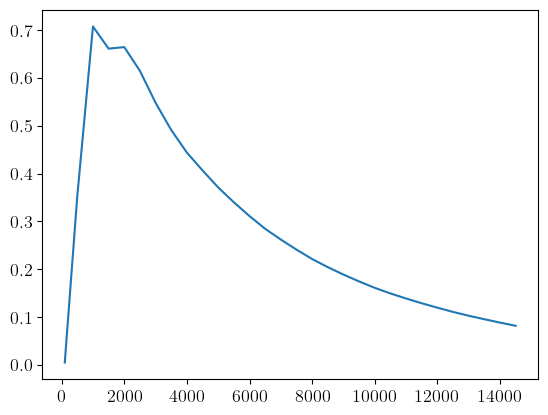

In [135]:
plt.plot(ells, fiducial)

### Surveys

We also need to assume some experimental noise configurations in order to generate our mock data. Here we plot the noise levels for each assumed survey setup.

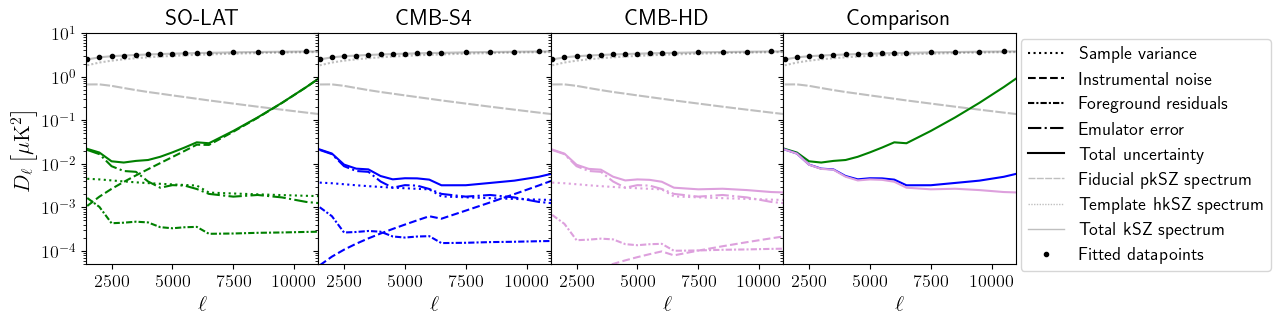

In [165]:
fig, ax = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,3))
fig.subplots_adjust(wspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator

from matplotlib.lines import Line2D

from alfred.parameters import colors

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle=(0, (3, 1, 1, 1)), alpha=1.0, label='Foreground residuals'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle=(0, (5, 1)), alpha=.25, linewidth=1.0, label=f'Fiducial pkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle=(0, (1, 1)), alpha=.25, linewidth=1.0, label=f'Template hkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.25, linewidth=1.0, label=f'Total kSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

data = np.load(f"{base_dir}/inference/productionruns6_addhksz/CMB-HD/noiseless/data.npz")
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells[indices], hksz[0], hksz[1])

fiducial = utils.spectra(config.sn)[indices] + 2.5 * hksz

ax[3].plot(ells[indices], fiducial, color='black', alpha=.25)
ax[3].plot(ells[indices], fiducial, color='black', marker='.', ls='')

ax[3].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.25, ls=(0, (5, 1)))
ax[3].plot(ells[indices], 2.5 * hksz, color='black', alpha=.25, ls=(0, (1, 1)))

for i, tele in enumerate(['SO-LAT', 'CMB-S4', 'CMB-HD']):

    ax[i].plot(ells[indices], fiducial, color='black', alpha=.25)
    ax[i].plot(ells[indices], fiducial, color='black', marker='.', ls='')

    ax[i].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.25, ls=(0, (5, 1)))
    ax[i].plot(ells[indices], 2.5 * hksz, color='black', alpha=.25, ls=(0, (1, 1)))

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, color=colors[i], ls=':')

    # Instrumental noise
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=True, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='noise' if i == 2 else None,
                color=colors[i], ls='--')

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=False, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls='dashdot')

    # Foreground residuals
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=False, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls=(0, (3, 1, 1, 1)))

    # Total uncertainty
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True, include_samplevar=True, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i])
    
    ax[i].set_title(f'{tele}', fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

    ax[3].plot(ells[indices], err, color=colors[i])

ax[2].plot([],[])

ax[3].set_title(f'Comparison', fontsize=16)
ax[3].set_xlabel(rf"$\ell$", fontsize=16)

ax[0].set_xlim(1450, 11000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=16)
ax[0].set_ylim(5e-5,10)
#ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].xaxis.set_major_locator(MultipleLocator(2500))
#ax[0].xaxis.set_minor_locator(MultipleLocator(500))
fig.legend(handles=legend_lines, loc='upper right', fontsize=13, bbox_to_anchor=(1.12, .89))

fig.savefig('surveys_comp.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


### Ionisation Histories and the Optical Depth, $\tau$

In [288]:
xe_histories = np.load(f"{base_dir}/metadata/xe_histories_from_spectra.npz", allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

In [ ]:
fig.savefig('xion_tau.png')

In [ ]:
diff, Planck_sn

(np.float64(0.014014080573021143), '15060')

In [ ]:
sim = Cat(Planck_sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        path_redshifts=redshift_file,
                        LoReLi_format=True,
                        verbose=False)
    
ksz = KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                    helium_interp=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                    xemax=.97)
        

fn = f'{home_dir}/nells30_v2/kSZ_LoReLi_simu{Planck_sn}.npz'
LoReLi = np.load(fn)

print(f"tau:{ksz.tau:.3f}")
print(f"tau:{ksz.tau + diff:.3f}")

tau:0.040
tau:0.054


## Mock Data
### Fiducial simulation

##### Homogeneous kSZ

In [55]:
true_params = np.asarray([*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())])
true_params

array([-1.71669877,  0.        ,  3.27712767,  8.53      ,  0.275     ,
        0.05526446])

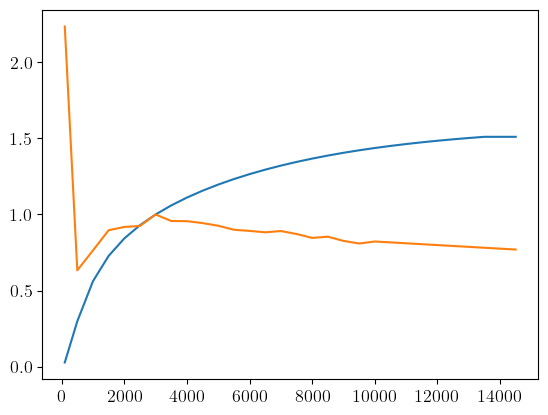

In [22]:
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells, hksz[0], hksz[1])

hksz2 = np.genfromtxt(f"{base_dir}/metadata/dl_homogeneous_ksz_shaw2012.txt").T
hksz2 = np.interp(ells, hksz2[0], hksz2[1])

plt.plot(ells, hksz)
plt.plot(ells, hksz2)

## Emulator performance and stability

Loading in our chosen emulator

### kSZ emulator

In [7]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)

nruns = 5
mob = []
for n in range(nruns):
    emu = summon_emu(f"{config.nndir}/emuv5.1_run{n}")
    mob.append(emu)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


plotting 39 sims...


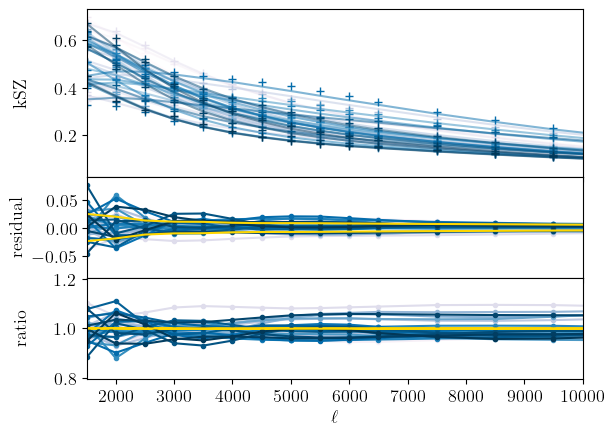

In [8]:
fig, ax = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios': [5, 3, 3]})
fig.subplots_adjust(wspace=0.0, hspace=0.0)

skipping = 35
sims_to_plot = validation_sims[::skipping]
print(f"plotting {len(sims_to_plot)} sims...")

N = len(sims_to_plot)
cmap = matplotlib.colormaps['PuBu']
    
# Generate N evenly spaced values in [0, 1]
ksz_colors = [cmap(i / (N - 1)) for i in range(N)]

data_ref = np.load(f"{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz")
std = np.load(f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy")

for i, sn in enumerate(sims_to_plot):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.kemu(df.loc[sn].to_numpy(), mob)

    ax[0].plot(ells[indices], tspec, marker='+', ls='', color=ksz_colors[i])
    ax[0].plot(ells[indices], espec, alpha=.5, color=ksz_colors[i])

    ax[1].plot(ells[indices], tspec - espec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], espec / tspec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], data_ref['Ashape'], color='gold')

ax[1].plot(ells[indices], -std, color='gold')
ax[1].plot(ells[indices], std, color='gold')

# a1.plot(x, y)
# a2.plot(x, y)

ax[0].set_xlim(1500,10000)
ax[1].set_ylim(-.09, .09)
ax[2].set_ylim(.795, 1.205)

ax[2].set_xlabel(rf"$\ell$")

ax[0].set_ylabel(rf"$\mathrm{{kSZ}}$")
ax[1].set_ylabel(rf"$\mathrm{{residual}}$")
ax[2].set_ylabel(rf"$\mathrm{{ratio}}$")

ax[0].yaxis.set_label_coords(-0.115, 0.5) 
ax[2].yaxis.set_label_coords(-0.115, 0.5) 

fig.savefig("NNemulator.png", bbox_inches='tight', pad_inches=0.05, dpi=300)

In [91]:
np.mean((utils.spectra(config.sn)[indices] / emulator.kemu(df.loc[config.sn].to_numpy(), mob)))


np.float64(1.042532116516509)

In [58]:
def degeneracy(Mmin, slope=priors2d['m'], intercept=priors2d['b_below']):
    return priors2d['m'] * Mmin + priors2d['b_below']

xMmin = np.linspace(*priors[3],10)
xtau = degeneracy(xMmin)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('viridis')
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` o

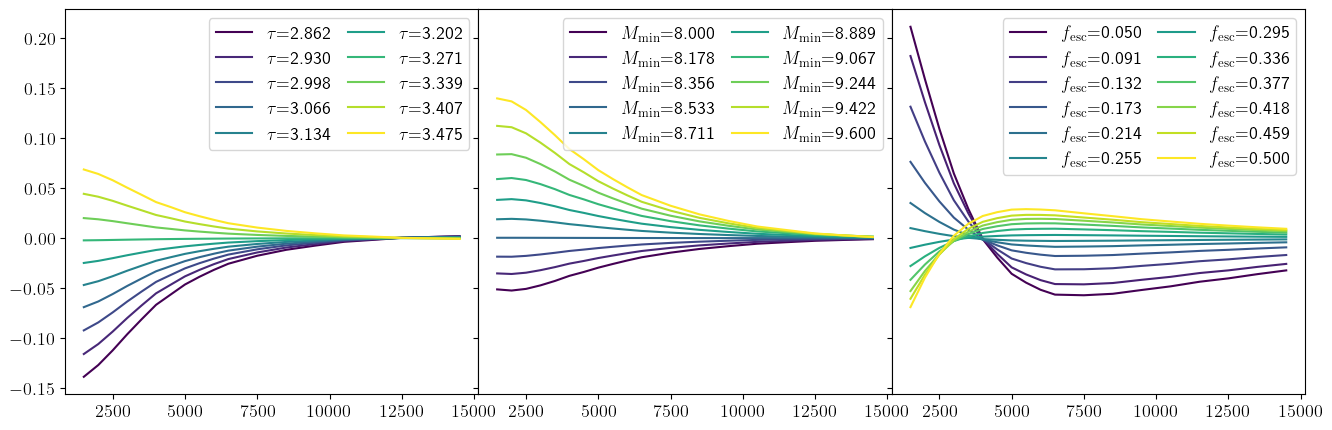

In [79]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(16,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

params_x = [xtau[::-1], xMmin, xfesc]

for i_param, prange in enumerate(params_x):
    N = len(prange)
    cmap = matplotlib.cm.get_cmap('viridis')
    
    # Generate N evenly spaced values in [0, 1]
    colors = [cmap(i / (N - 1)) for i in range(N)]
    for it, t in enumerate(prange):
        params = cp.deepcopy(true_params[:-1])
        params[2+i_param] = t
        espec = emulator.mechkemu(params, mob)
        label = rf"{astro_pnames_formatted[2+i_param]}$=${t:.3f}"
        ax[i_param].plot(ells[indices], tspec - espec, color=colors[it], label=label)
        ax[i_param].legend(ncol=2, columnspacing=1.0, fontsize=13)

fig.savefig('x_vs_dkSZ.png', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [44]:
samples

array([[-2.79721189,  0.19627005,  3.66770594,  8.04797253,  0.42621474],
       [-2.32323812,  0.17636773,  3.31828961,  9.55882617,  0.13174127],
       [-3.66792151,  0.11632865,  3.27298402,  8.83525598,  0.1073423 ],
       ...,
       [-2.84047047,  0.03494826,  3.18765722,  9.52513095,  0.06699478],
       [-2.53079057,  0.13263233,  3.92487386,  8.11045816,  0.27302342],
       [-3.03547066,  0.5471112 ,  3.46611226,  8.64786835,  0.34987466]],
      shape=(1000, 5))

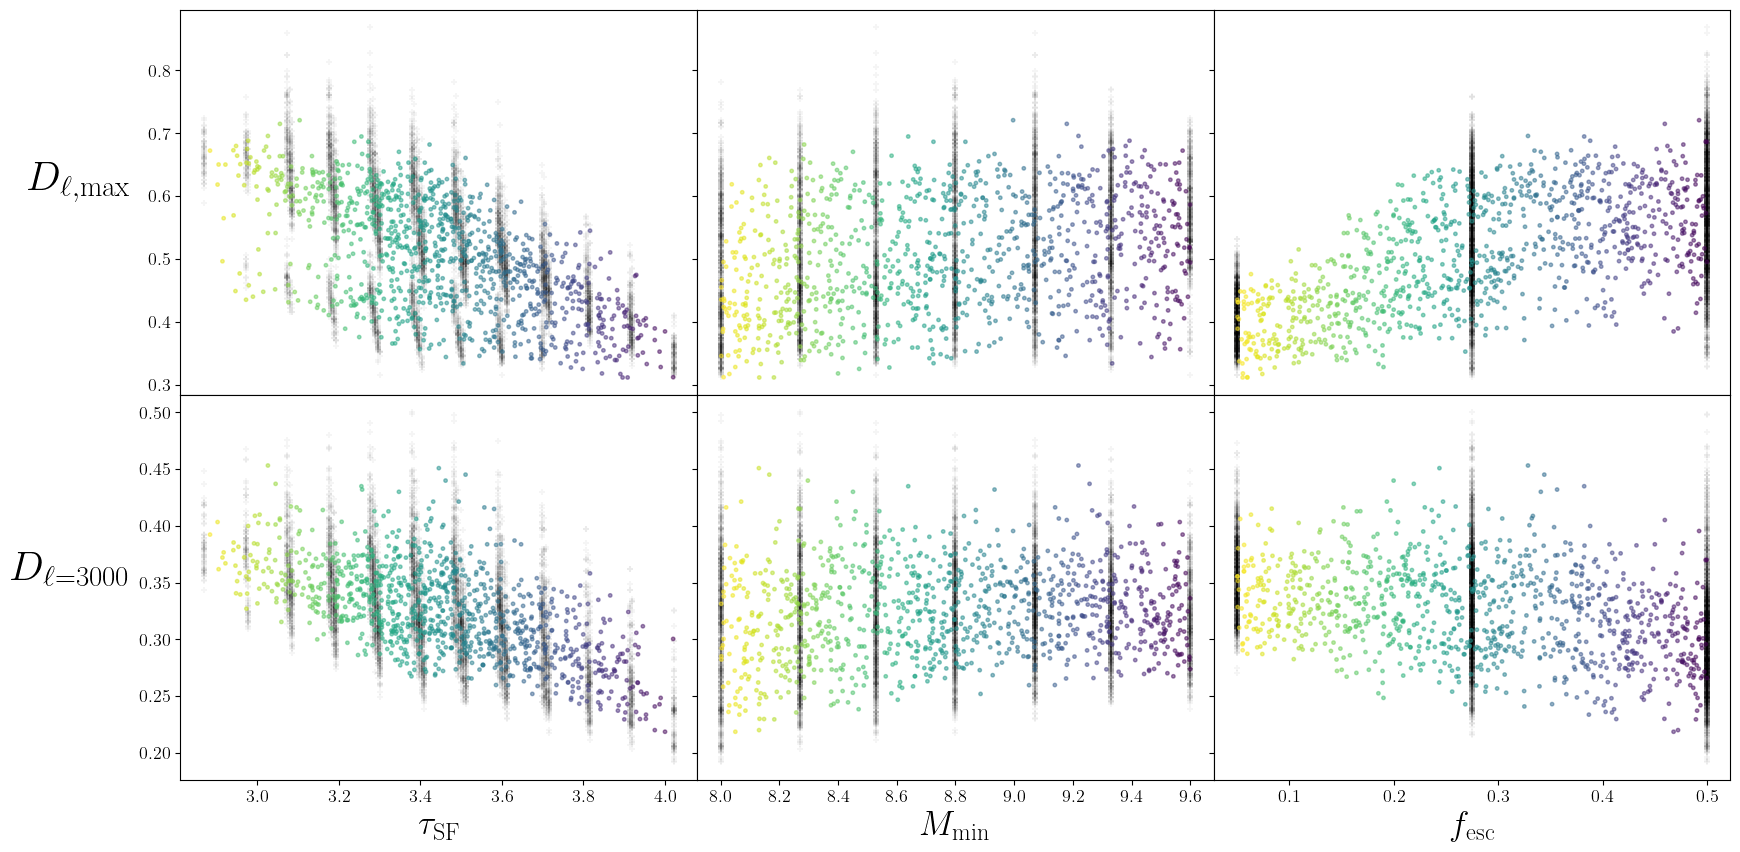

In [45]:
fig, ax = plt.subplots(2,len(df.columns.to_list()[2:]), sharex='col', sharey='row', figsize=(20,10))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

samples = draws(1000)

params = df.to_numpy()
data = np.zeros((len(df), len(ells[indices])))
for i_sim, sn in enumerate(df.index):
    data[i_sim] = utils.spectra(sn)[indices]
    
signal = emulator.kemu(samples, mob)
color = cmap(norm(params[-1]))

skwargs = {'marker':'.', 
           's':25,
           'alpha':.5,
           'color':color,
           'rasterized': True}

for i, pname in enumerate(df.columns.to_list()[2:]):
    skwargs['marker'] = '+'
    skwargs['alpha'] = .04
    skwargs['color'] = 'black'

    ax[0,i].scatter(params[:,2+i], np.max(data, axis=1), **skwargs)
    # ax[1,i].scatter(params[:,i], ells[indices][np.argmax(data[:,1:], axis=1)], **skwargs)
    ax[1,i].scatter(params[:,2+i], data[:,4], **skwargs)

    skwargs['color'] = cmap(norms[2+i](samples[:,2+i]))
    skwargs['marker'] = '.'
    skwargs['alpha'] = .5

    ax[0,i].scatter(samples[:,2+i], np.max(signal, axis=1), **skwargs)
    # ax[1,i].scatter(samples[:,i], ells[indices][np.argmax(signal, axis=1)], **skwargs)
    ax[1,i].scatter(samples[:,2+i],  signal[:,4], **skwargs)

    ax[1,i].set_xlabel(astro_pnames_formatted[2+i], fontsize=25)

ax[0, 0].set_ylabel(r"$D_{\ell, \mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
# ax[1, 0].set_ylabel(r"$\ell_{\mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[1, 0].set_ylabel(r"$D_{\ell=3000}$", fontsize=30, rotation=0, labelpad=50)

# ax[1,0].set_ylim(1000, 3000)

fig.savefig('trends2.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)



### X_e emulator

In [145]:
xe_histories = np.load(f'{home_dir}/alfred/ionisation_histories_with_optical_depth.npz', allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

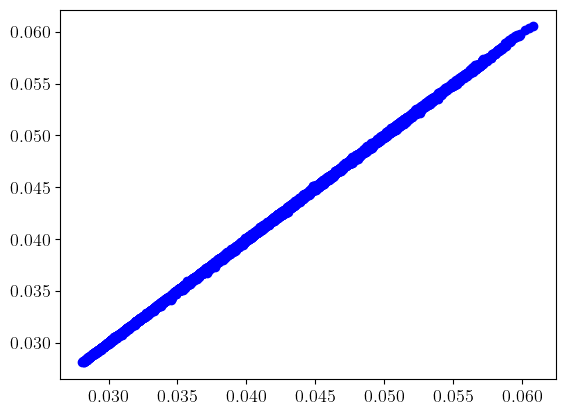

In [156]:
fig = plt.figure()

residuals = []

for key, item in xe_histories.items():
    temu = item['tau_emu']
    demu = item['tau_data']

    residuals.append(np.abs(temu - demu))

    plt.scatter(demu, temu, color='blue')
    

In [157]:
np.mean(residuals)

np.float64(7.448011129040616e-05)

# Section 4     Results

### Gorce hkSZ template

In [169]:
mcmcdir = f"{base_dir}/inference/productionruns7_addhksz"
survey_list = ['SO-LAT', 'CMB-S4', 'CMB-HD']
data = np.load(f"{mcmcdir}/{survey_list[2]}/noiseless/data.npz")

chains = []

# s, l = utils.load_samples(f"{base_dir}/inference/productionruns6_justpriors/CMB-HD/noiseless")
# chains.append(s)

# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.subplots_adjust( wspace=0.0, hspace=0.0)

# norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
# cmap = plt.get_cmap('viridis_r')

# ztau = np.linspace(5,15,10)

for i, s in enumerate(survey_list):
    s, l = utils.load_samples(f"{mcmcdir}/{s}/noiseless")
    print(f"shape:", s.shape)
    chains.append(s)
    # params = fill(s, df.loc[config.sn].to_dict(), df.columns[2:])
    # xe = keras_xe_emul.xe_emul_array(ztau, params, plot=False)

    # for n in range(1,10000,1000):
    #     ax[i].semilogy(ztau, xe[n].T, color=cmap(norm(params[n,-1])))



Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/SO-LAT/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-S4/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/noiseless...
shape: (120000, 5)


1.0043749667716018


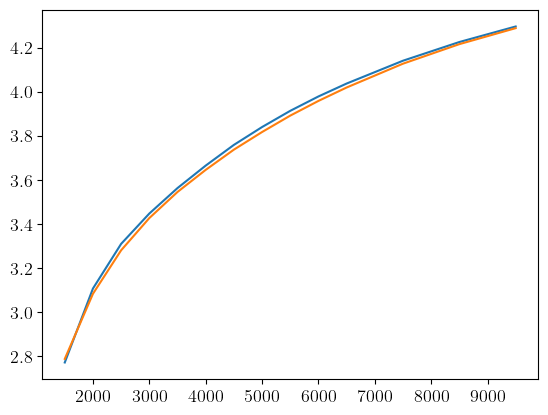

In [170]:
plt.plot(data['ells'], data['datapoints'])
plt.plot(data['ells'], data['model'])

print(np.mean(data['datapoints'] / data['model']))

In [75]:
chaintau.shape

(120000, 6)

In [103]:
true_values

{'$\\tau_{\\mathrm{SF}}$': np.float64(3.277127671229863),
 '$M_{\\mathrm{min}}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05526446348700878),
 '$A_{\\mathrm{bias}}$': np.float64(1.042532116516509),
 '$A_{\\mathrm{hkSZ}}$': 2.9}

<string>:38: RuntimeWarning: divide by zero encountered in log10


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless...


<string>:38: RuntimeWarning: divide by zero encountered in log10


1 0
2 0
2 1
3 0
3 1
3 2


<string>:38: RuntimeWarning: divide by zero encountered in log10
<string>:38: RuntimeWarning: divide by zero encountered in log10


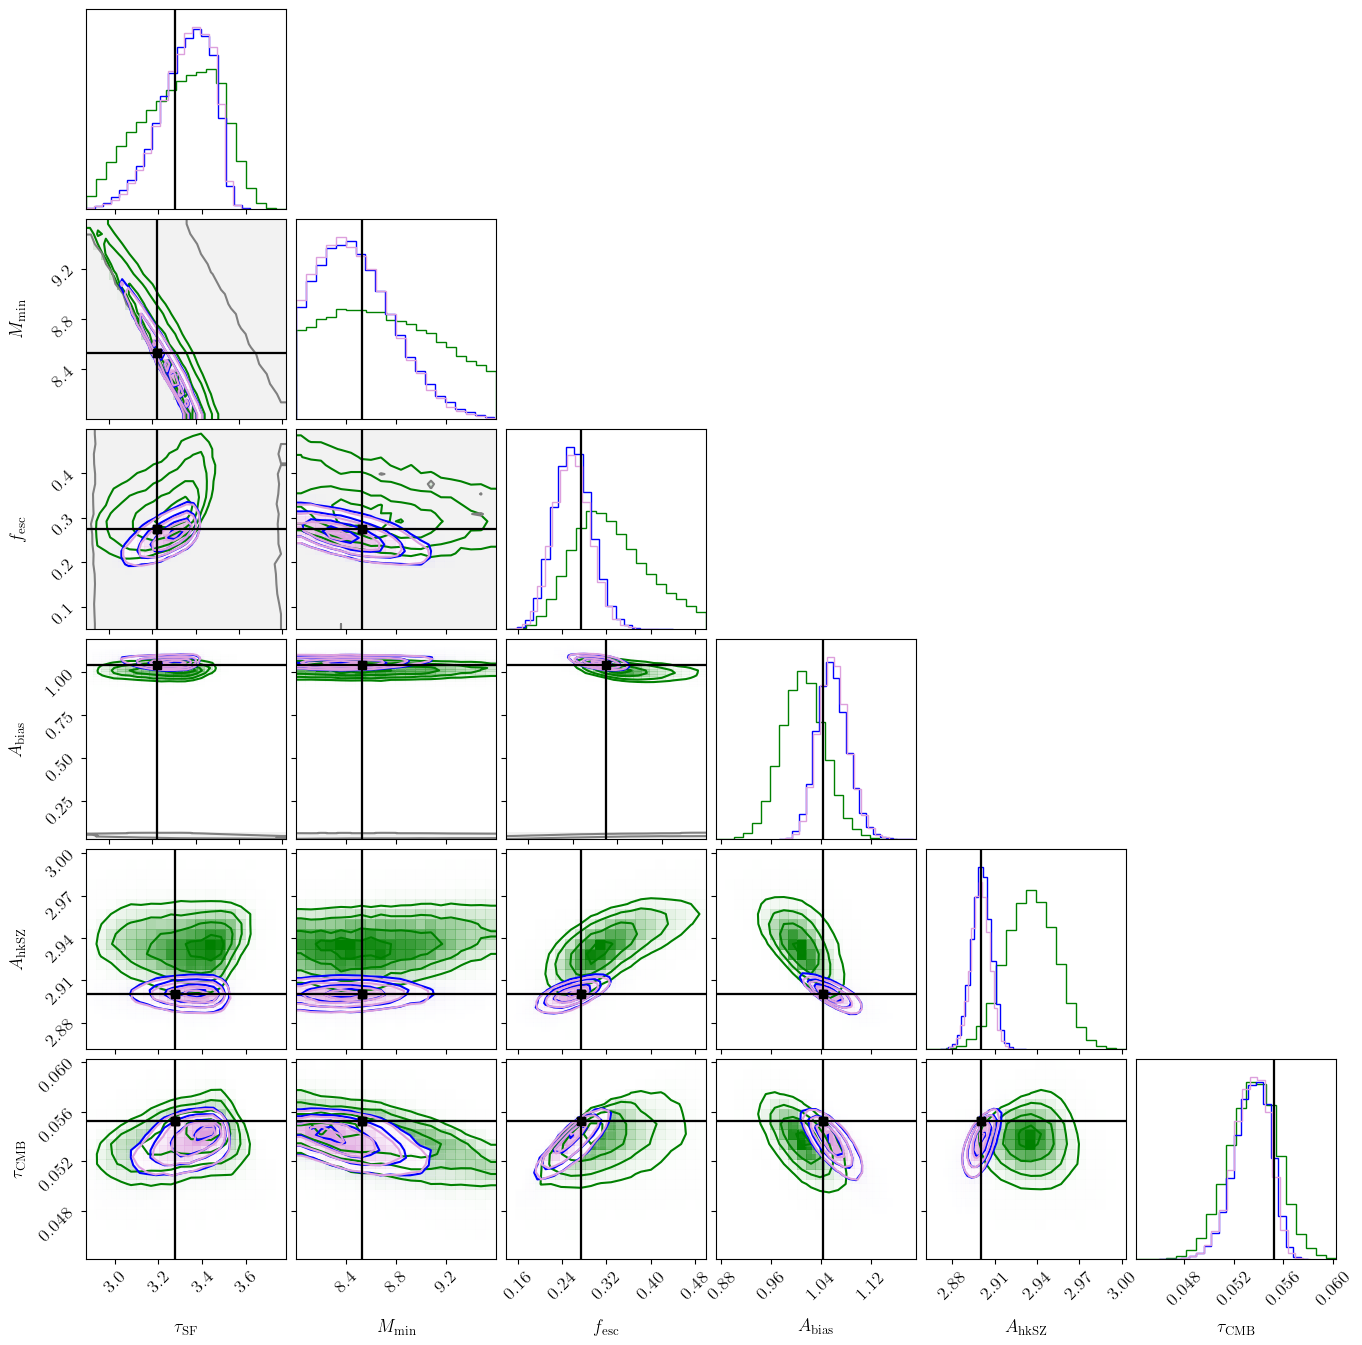

In [175]:
# pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']
pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$',
    '$\\tau_{\\mathrm{CMB}}$']

true_params = [*df.loc[config.sn].to_numpy()]
true_values = dict(zip(pnames, [*true_params[2:], np.mean(utils.spectra(config.sn)[indices] / alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)), 2.9, *whatthetau(df.loc[config.sn].to_numpy())]))

cornerfig = None

color = colors[0]
chaintau = make_tauchains(chains[0][:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
a = chains[0]
b = chaintau[:,-1][:,None]
chaintau = cp.deepcopy(np.concatenate([a, b], axis=1))

#  np.save(f'samples_wtau_{survey_list[i]}', chaintau)
cornerfig = corner.corner(chaintau, fig=cornerfig, color=color,
                    truth_color='black', truths=list(true_values.values()), labels=pnames,
                   plot_datapoints=False, plot_density=True)

axes = np.array(cornerfig.axes).reshape((len(pnames), len(pnames)))

s, l = utils.load_samples(f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/noiseless")
chainpriors = make_tauchains(s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
#chainpriors = cp.deepcopy(np.concatenate([s, chainpriors[:,-1]], axis=1))
for pi in range(4):
    for pj in range(pi):
        print(pi, pj)
        ax = axes[pi,pj]
        corner.hist2d(chainpriors[:,pj], chainpriors[:,pi], ax=ax, plot_datapoints=False, plot_contours=True,
                      plot_density=False, color='grey', zorder=0, levels=[.99], fill_contours=True, no_fill_contours=False,
                     contourf_kwargs={'alpha':0.1})
        if pi != 0:
            ax.set_xticklabels([])
            ax.set_yticklabels([])

for pi in range(4):
    ax = axes[pi,pi]
    ax.hist(chainpriors[:,pi], density=True, color='red', zorder=0)

for i, chain in enumerate(chains[1:]):
    color = colors[i+1]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    a = chain
    b = chaintau[:,-1][:,None]
    chaintau = cp.deepcopy(np.concatenate([a,b], axis=1))

  #  np.save(f'samples_wtau_{survey_list[i]}', chaintau)
    cornerfig = corner.corner(chaintau, fig=cornerfig, color=color,
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    

cornerfig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [127]:
a = chains[0]
b = chaintau[:,-1][:,None]

In [128]:
print("a.shape:", a.shape)
print("b.shape:", b.shape)
print("a.ndim:", a.ndim)
print("b.ndim:", b.ndim)
print("a.dtype:", a.dtype)
print("b.dtype:", b.dtype)
print("type(a):", type(a))
print("type(b):", type(b))

c = np.concatenate((a, b), axis=1)
print("Concatenated shape:", c.shape)


a.shape: (120000, 5)
b.shape: (120000, 1)
a.ndim: 2
b.ndim: 2
a.dtype: float64
b.dtype: float64
type(a): <class 'numpy.ndarray'>
type(b): <class 'numpy.ndarray'>
Concatenated shape: (120000, 6)


In [126]:
import numpy as np

a = np.random.rand(120000, 5)
b = np.random.rand(120000, 1)

print("a.shape:", a.shape)
print("b.shape:", b.shape)
print("a.ndim:", a.ndim)
print("b.ndim:", b.ndim)
print("a.dtype:", a.dtype)
print("b.dtype:", b.dtype)
print("type(a):", type(a))
print("type(b):", type(b))

c = np.concatenate((a, b), axis=1)
print("Concatenated shape:", c.shape)


a.shape: (120000, 5)
b.shape: (120000, 1)
a.ndim: 2
b.ndim: 2
a.dtype: float64
b.dtype: float64
type(a): <class 'numpy.ndarray'>
type(b): <class 'numpy.ndarray'>
Concatenated shape: (120000, 6)


In [132]:
np.all(b == chaintau[:,-1].reshape(-1, 1))

np.True_

In [136]:
print(chains[0].shape)
print(chaintau[:,-1].reshape(-1, 1).shape)
np.concatenate([a, b], axis=1)

(120000, 5)
(120000, 1)


array([[3.10163812, 9.3381668 , 0.27560378, 1.0290251 , 2.94042655,
        0.05468414],
       [3.54364442, 8.16292716, 0.34497866, 1.0447815 , 2.92579501,
        0.05266162],
       [3.45579848, 8.19991034, 0.42845166, 0.92764836, 2.95761282,
        0.0541062 ],
       ...,
       [3.48812983, 8.49423018, 0.48016074, 0.96810137, 2.97733024,
        0.05506853],
       [3.23659218, 8.88054262, 0.38902097, 0.98906052, 2.94601487,
        0.05191771],
       [3.49743202, 8.31440587, 0.34182822, 1.02867617, 2.9375267 ,
        0.05319891]], shape=(120000, 6))

### Shaw2012 Template

In [149]:
mcmcdir = f"{base_dir}/inference/productionruns7_addhksz_Shaw2012"
survey_list = ['SO-LAT', 'CMB-S4', 'CMB-HD']
data = np.load(f"{mcmcdir}/{survey_list[2]}/noiseless/data.npz")

chains = []

# s, l = utils.load_samples(f"{base_dir}/inference/productionruns6_justpriors/CMB-HD/noiseless")
# chains.append(s)

# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.subplots_adjust( wspace=0.0, hspace=0.0)

# norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
# cmap = plt.get_cmap('viridis_r')

# ztau = np.linspace(5,15,10)

for i, s in enumerate(survey_list):
    s, l = utils.load_samples(f"{mcmcdir}/{s}/noiseless")
    print(f"shape:", s.shape)
    chains.append(s)
    # params = fill(s, df.loc[config.sn].to_dict(), df.columns[2:])
    # xe = keras_xe_emul.xe_emul_array(ztau, params, plot=False)

    # for n in range(1,10000,1000):
    #     ax[i].semilogy(ztau, xe[n].T, color=cmap(norm(params[n,-1])))



Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/SO-LAT/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/CMB-S4/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/CMB-HD/noiseless...
shape: (120000, 5)


1.0053820096415385


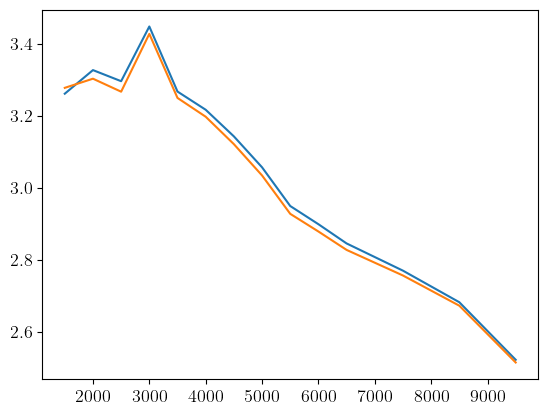

In [16]:
plt.plot(data['ells'], data['datapoints'])
plt.plot(data['ells'], data['model'])

print(np.mean(data['datapoints'] / data['model']))

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


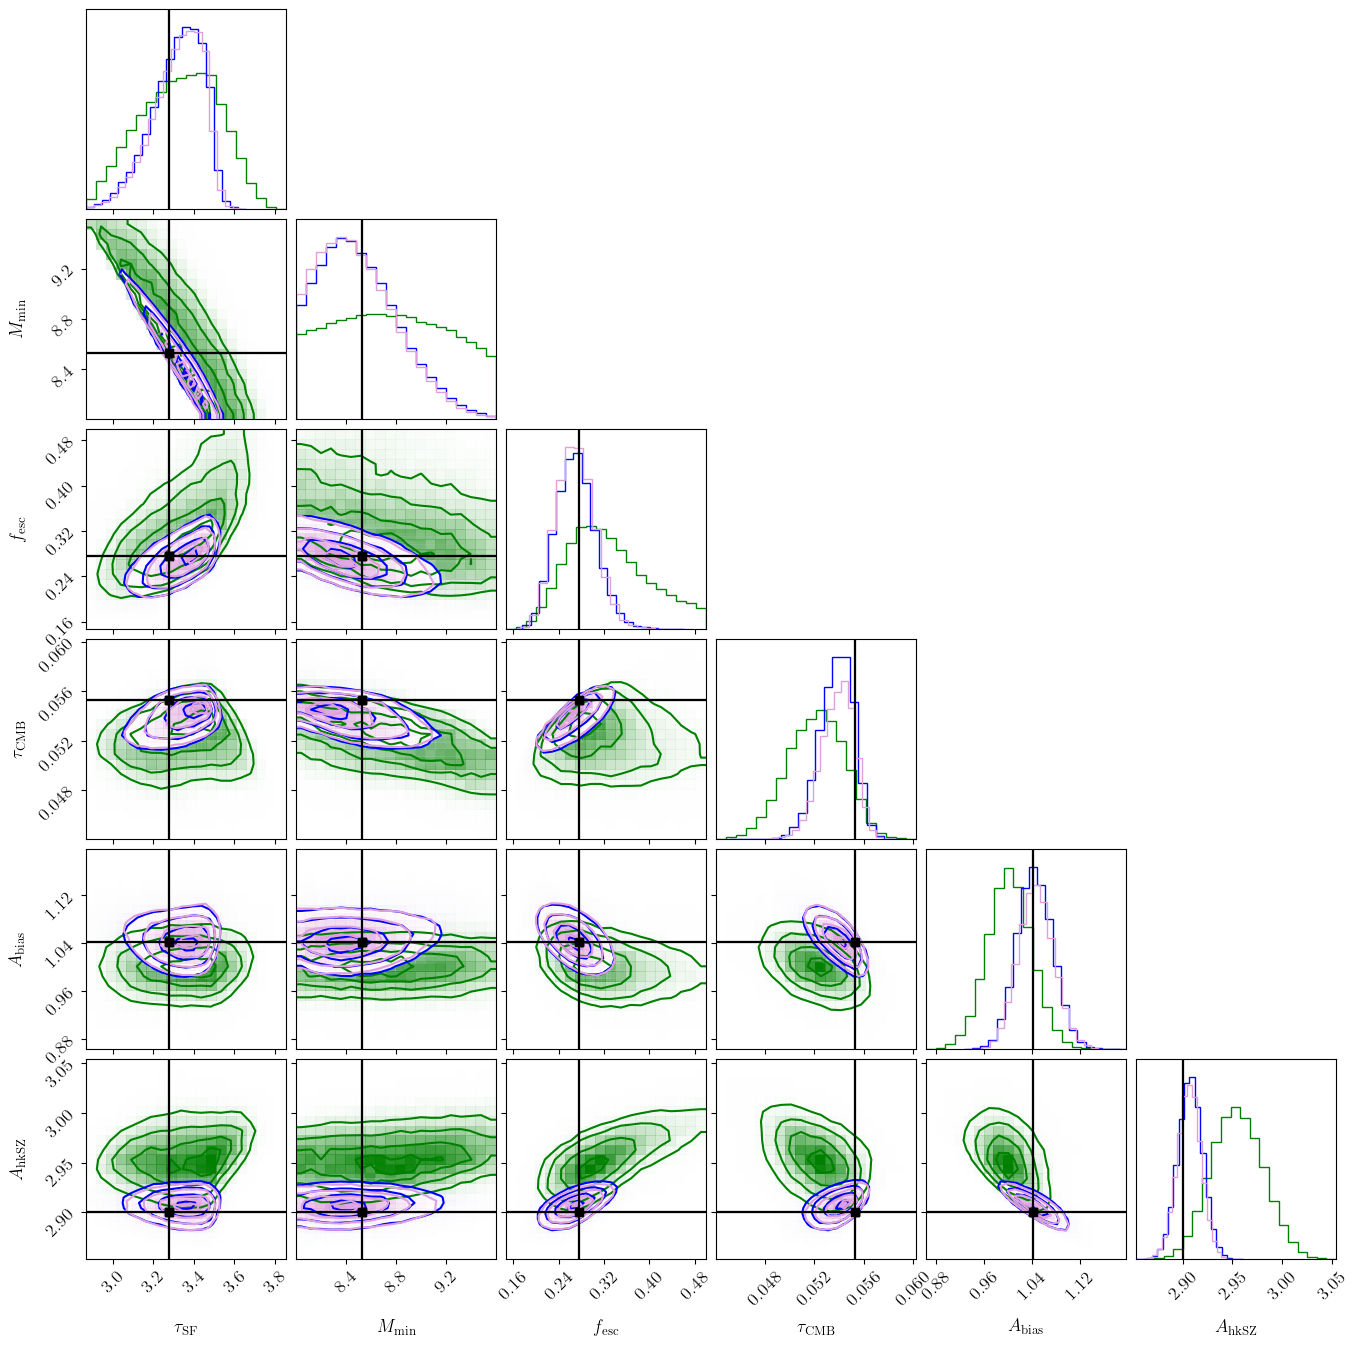

In [43]:
# pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']
pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$\\tau_{\\mathrm{CMB}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$']

#true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
#true_values = dict(zip(pnames, [*true_params[2:], np.mean(data['datapoints'] / data['model']), 2.9]))

cornerfig = None

for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    np.save(f'samples_wtau_{survey_list[i]}', chaintau)
    fig = corner.corner(chaintau, fig=cornerfig, color=color,
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    cornerfig = fig

#cornerfig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

## A Giant Corner Plot

In [49]:
redshifts(xe_histories[config.sn]['z'], xe_histories[config.sn]['xe'])

(np.float64(7.642022944507361), np.float64(0.7506651008737153))

In [165]:
def redshifts(xe, z=np.linspace(20,5,100)):
    ion_fracs = [.25, .5, .75]

    z_tiled = np.tile(z, (xe.shape[0], 1))
    z_values = np.array([np.interp(ion_fracs, xe_row, z_tiled_row) for xe_row, z_tiled_row in zip(xe, z_tiled)])
    
    # Now z_values will have shape (N, 3), with z25, z50, z75 for each row in xe
    z25, z50, z75 = z_values[:, 0], z_values[:, 1], z_values[:, 2]
    duration = z25 - z75

    return z50, duration


true_z50, true_duration = redshifts(xe_histories[config.sn]['xe'][None,:], xe_histories[config.sn]['z'][None,:])
true_Dpksz = alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)[3]
true_D3000 = true_Dpksz + 2.9

true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
pnames = pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$\\tau_{\\mathrm{CMB}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$',
    '$z_{50}$',
    '$\Delta z$',
    '$D_{3000}$',
    '$D_{\\mathrm{pksz}}$']
pvals = [*true_params[2:], np.mean(utils.spectra(config.sn)[indices] / alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)),
                        2.9, true_z50, true_duration, true_D3000, true_Dpksz]
pvals = np.ravel(np.array(pvals, dtype=object)).astype(np.float64)
true_values = dict(zip(pnames, pvals))
   

<string>:38: RuntimeWarning: divide by zero encountered in log10
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_96902/3907074309.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pvals = np.ravel(np.array(pvals, dtype=object)).astype(np.float64)


In [162]:
true_values

{'$\\tau_{\\mathrm{SF}}$': np.float64(3.277127671229863),
 '$M_{\\mathrm{min}}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05526446348700878),
 '$A_{\\mathrm{bias}}$': np.float64(1.042532116516509),
 '$A_{\\mathrm{hkSZ}}$': np.float64(2.9),
 '$z_{50}$': np.float64(7.642022944507361),
 '$\\Delta z$': np.float64(0.7506651008737153),
 '$D_{3000}$': np.float64(3.42832350730896),
 '$D_{\\mathrm{pksz}}$': np.float64(0.5283233523368835)}

<string>:38: RuntimeWarning: divide by zero encountered in log10
<string>:38: RuntimeWarning: divide by zero encountered in log10
<string>:38: RuntimeWarning: divide by zero encountered in log10
python(96338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96340) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


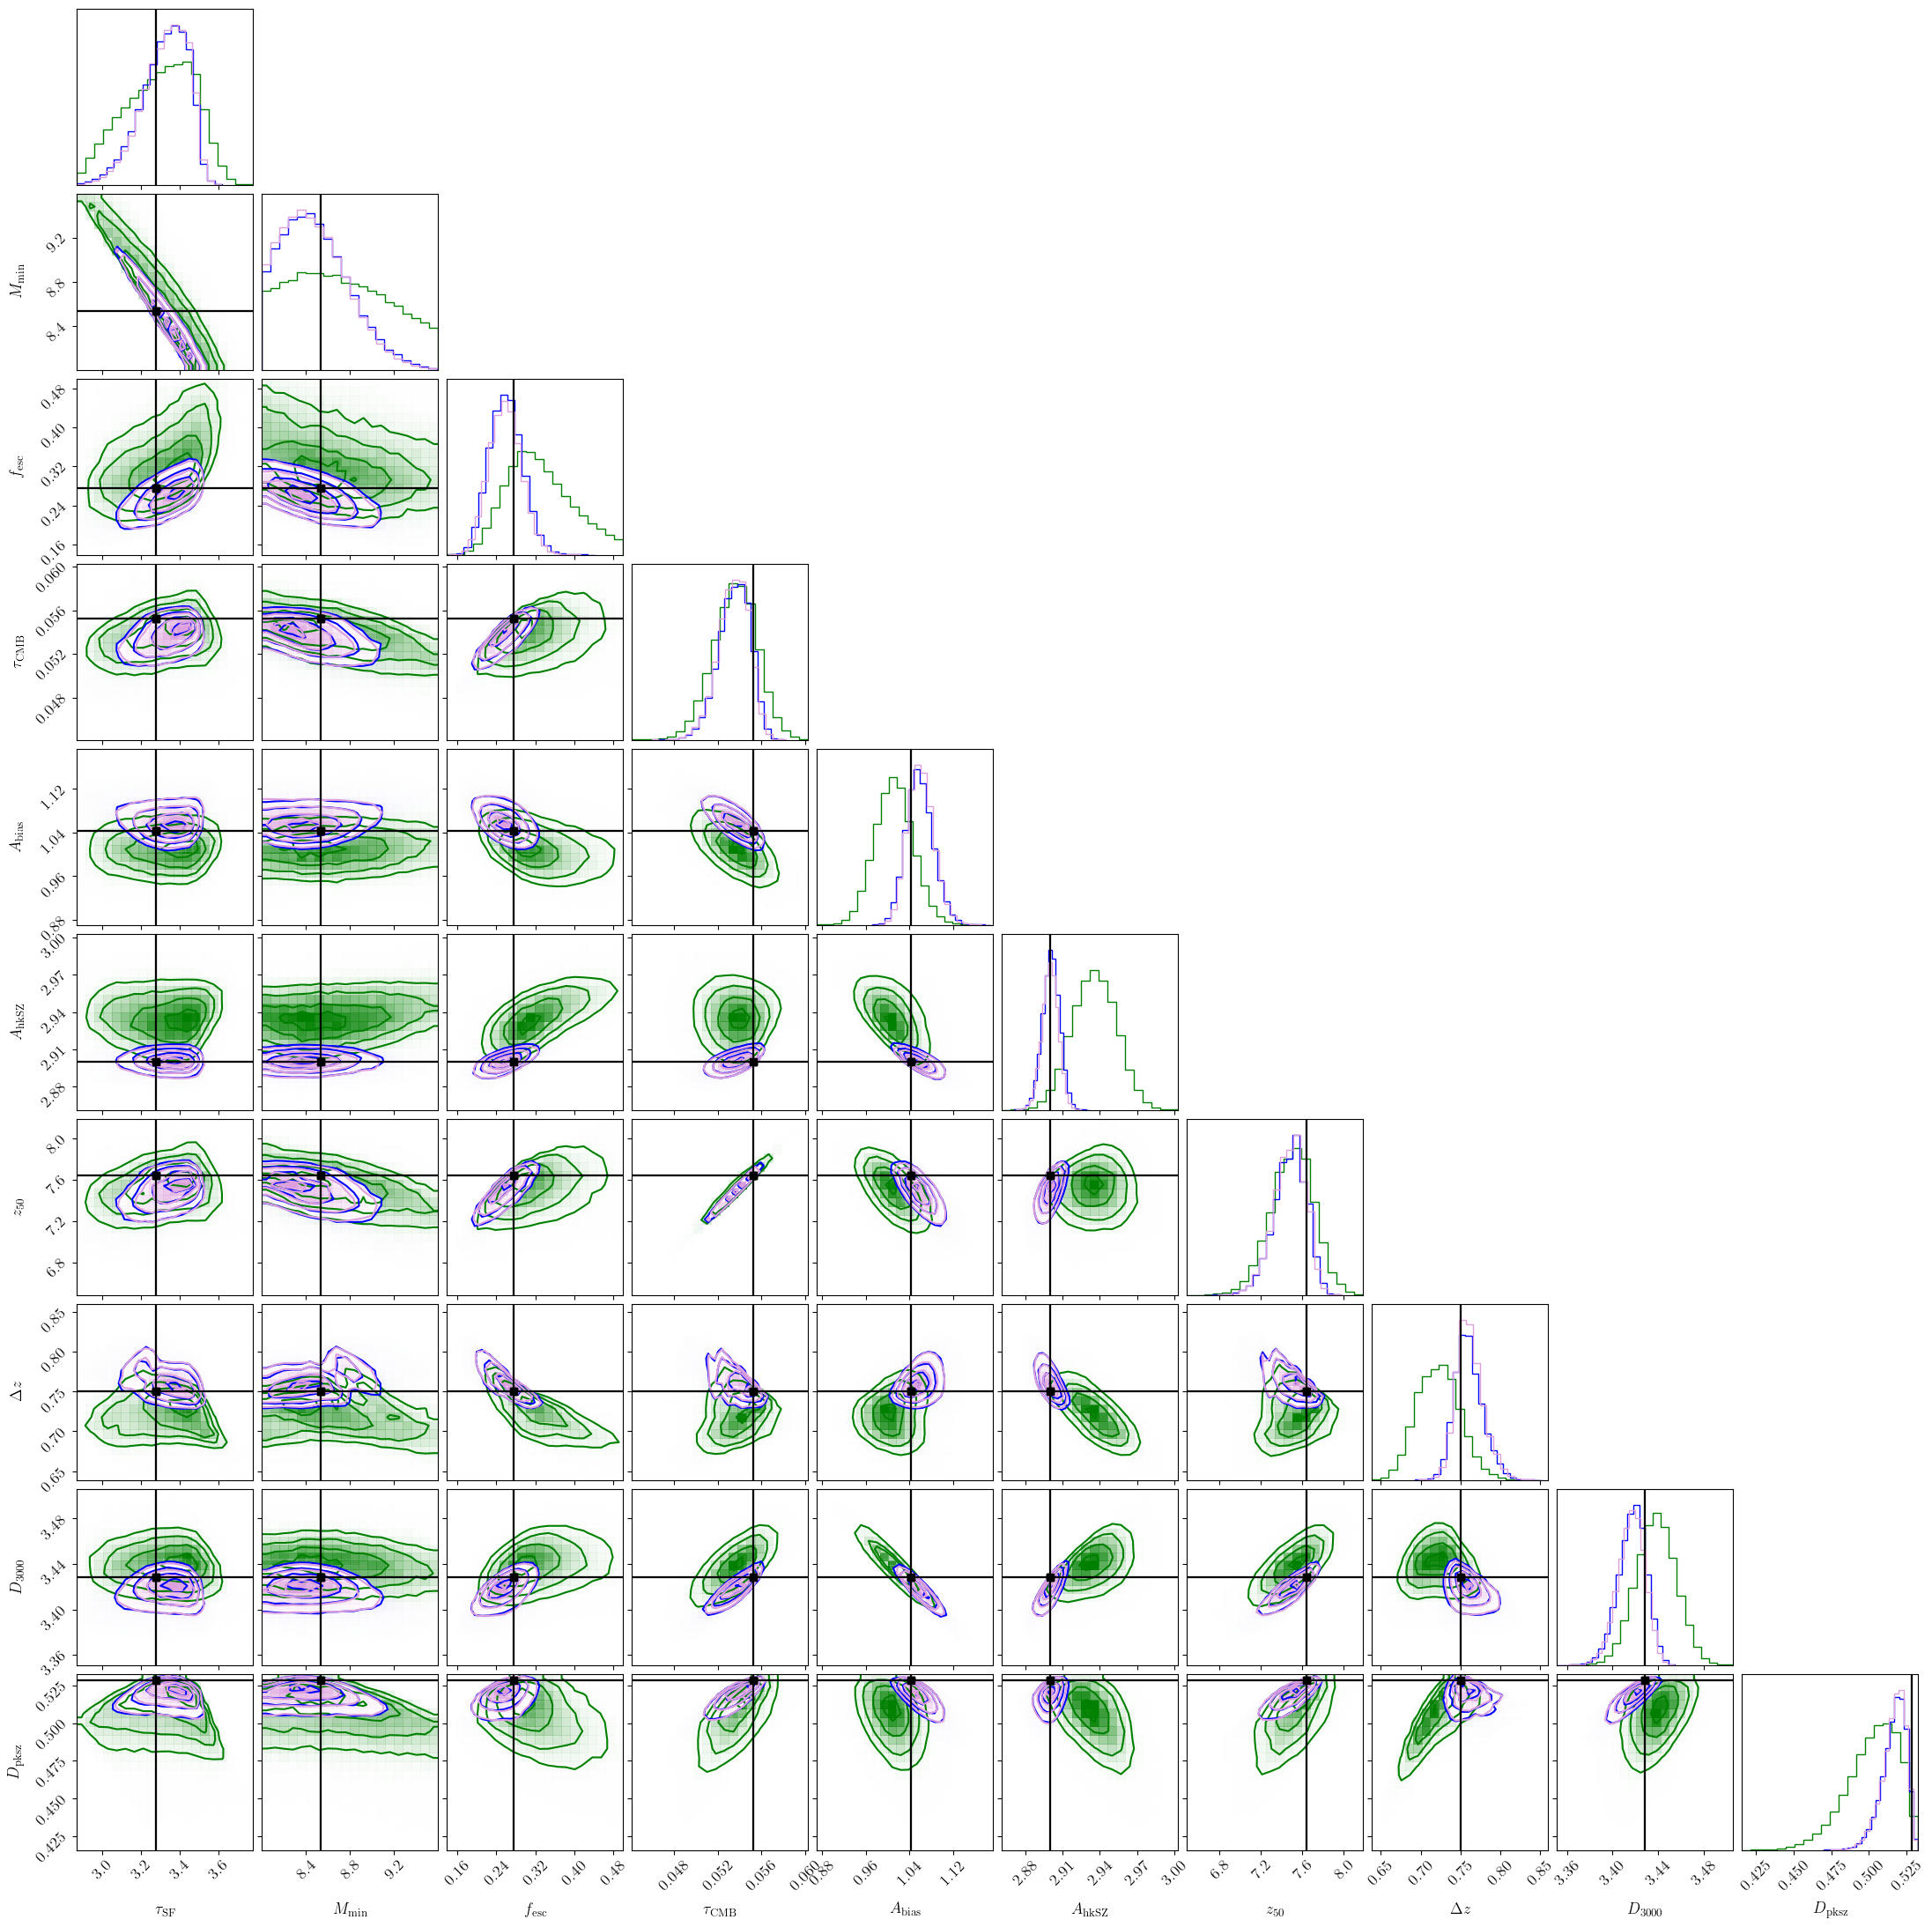

In [166]:
cornerfig = None

z = np.linspace(20,5,100)

samples_derived = []
for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    params = fill(chain[:,:3], df.loc[config.sn].to_dict())
    xemu = keras_xe_emul.xe_emul_array(z, params, plot=False, He1=False, He2=False)
    z50, duration = redshifts(xemu)

    signal = alfred.emulator.kemu(params, mob)
    D_pksz = signal[:,3]
    D_3000 = D_pksz + chaintau[:,-1]

    chaintau = cp.deepcopy(np.concatenate([chaintau, z50[:,None], duration[:,None], D_3000[:,None], D_pksz[:,None]], axis=1))
    samples_derived.append(chaintau)

    fig = corner.corner(chaintau, fig=cornerfig, color=color,
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    cornerfig = fig

In [167]:
for si, chains in enumerate(samples_derived):
    print('------------------------') 
    print(f'survey {survey_list[si]}')
    print('------------------------')
    for i, (pn, pv) in enumerate(true_values.items()):
        samples = chains[:,i]
        median_val = np.median(samples)
        
        # 68% credible interval (asymmetric)
        low, high = np.percentile(samples, [16, 84])
        low_err = median_val - low
        high_err = high - median_val
        
        # Bias and normalized bias
        bias = median_val - pv

        if bias <= 0.0:
            sigma_bias = low_err
        elif bias > 0.0:
            sigma_bias = high_err
        # sigma_68_sym = 0.5 * (high - low)  # for bias/σ, use symmetric approx
        bias_over_sigma = bias / sigma_bias

        print(f"for parameter {pn}")
        print(f"\t median : {median_val}")
        print(f"\t bias : {bias}")
        print(f"\t lowerr : {low_err}")
        print(f"\t higherr : {high_err}")
        print(f"\t bias / CI : {bias_over_sigma}")
        

------------------------
survey SO-LAT
------------------------
for parameter $\tau_{\mathrm{SF}}$
	 median : 3.3128772592236357
	 bias : 0.03574958799377281
	 lowerr : 0.21269546813874163
	 higherr : 0.16769379770977633
	 bias / CI : 0.2131837222485937
for parameter $M_{\mathrm{min}}$
	 median : 8.688892923637212
	 bias : 0.15889292363721275
	 lowerr : 0.447840229286399
	 higherr : 0.525266805962703
	 bias / CI : 0.30249945710160686
for parameter $f_{\mathrm{esc}}$
	 median : 0.32233941431313495
	 bias : 0.04733941431313493
	 lowerr : 0.05906822227894204
	 higherr : 0.07988209712163513
	 bias / CI : 0.5926160681667132
for parameter $\tau_{\mathrm{CMB}}$
	 median : 0.05364992575805113
	 bias : -0.0016145377289576504
	 lowerr : 0.0020691398899582783
	 higherr : 0.0018979443146348793
	 bias / CI : -0.78029413902518
for parameter $A_{\mathrm{bias}}$
	 median : 1.0108587312345598
	 bias : -0.031673385281949074
	 lowerr : 0.034190474177914876
	 higherr : 0.034912888327801817
	 bias / CI : -

In [160]:
true_values

{'$\\tau_{\\mathrm{SF}}$': np.float64(3.277127671229863),
 '$M_{\\mathrm{min}}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05526446348700878),
 '$A_{\\mathrm{bias}}$': np.float64(1.042532116516509),
 '$A_{\\mathrm{hkSZ}}$': np.float64(2.9),
 '$z_{50}$': np.float64(7.642022944507361),
 '$\\Delta z$': np.float64(0.7506651008737153),
 '$D_{3000}$': np.float64(3.42832350730896),
 '$D_{\\mathrm{pksz}}$': np.float64(0.5283233523368835)}

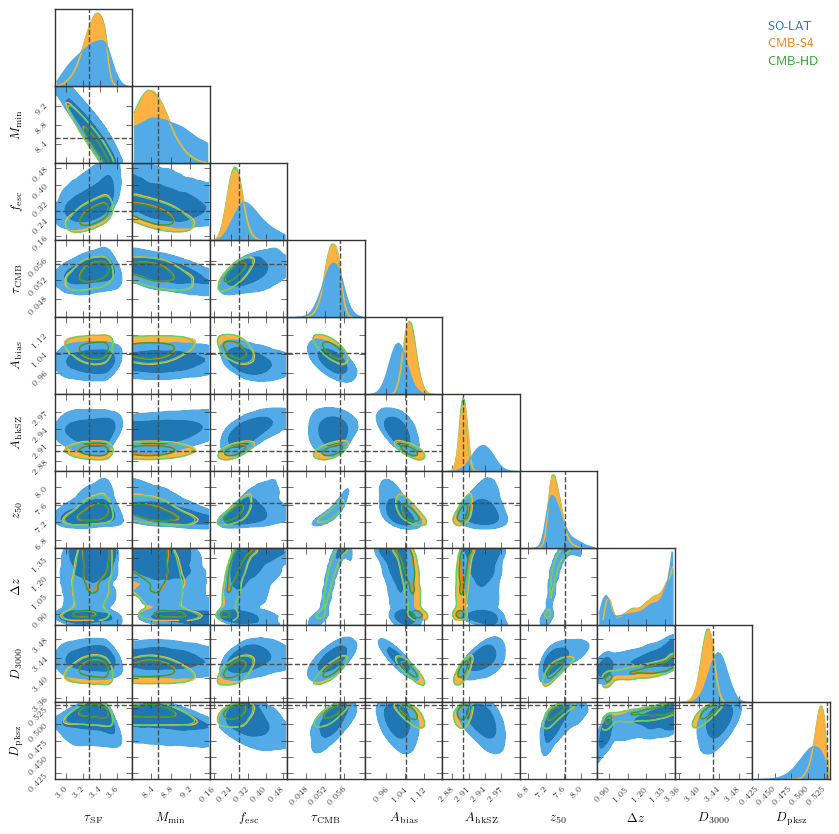

In [101]:
# # List of parameter names, supports latex
# # NOTE: For capital greek letters in latex mode, use \mathsf{}
# names = ['param name',
#          '$B_\mathrm{\lambda}$',
#          '$E$', '$\\lambda$',
#          'C',
#          'D',
#          '$\mathsf{\Omega}$',
#          '$\\gamma$']

# # Labels for the different chains
# chainLabels = ["data1 $\lambda$",
#                "data 2"]

# # List of Gaussian curves to plot
# #(to represent priors): mean, width
# # Empty () or None if no prior to plot
# priors = ((2, 1),
#           (-1, 2),
#           (),
#           (0, .4),
#           None,
#           (1,1),
#           None,
#           None)

# # List of truth values, to mark best-fit or input values
# # NOT a python array because of different lengths
# # Here we choose two sets of truth values
# truths = ((4, .5, None, .1, 0, None, None, 0),
#           (None, None, .3, 1, None, None, None, None))

# # Labels for the different truths
# truthLabels = ( 'the truth',
#                'also true')
import pygtc
# Do the magic
GTC = pygtc.plotGTC(chains=samples_derived,
                    paramNames=pnames,
                    chainLabels=survey_list,
                    truths=list(true_values.values()),
                    figureSize=AandA_page)
               #     truthLabels=truthLabels)


In [66]:
for i, chain in enumerate(chains[:1]):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    params = fill(chain[:,:3], df.loc[config.sn].to_dict())
    xemu = keras_xe_emul.xe_emul_array(z, params, plot=False, He1=False, He2=False)
    z50, duration = redshifts(xemu)

    signal = alfred.emulator.kemu(params, mob)
    D_pksz = signal[:,3]
    D_3000 = D_pksz + chaintau[:,-1]

    chaintau = cp.deepcopy(np.concatenate([chaintau, z50[:,None], duration[:,None], D_3000[:,None], D_pksz[:,None]], axis=1))

  #  fig = corner.corner(chaintau)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


In [ ]:
si

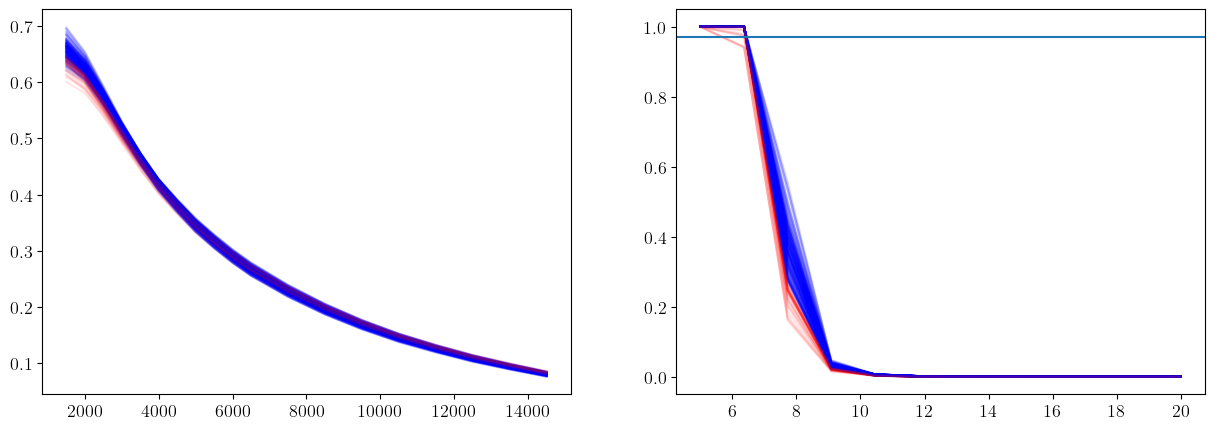

In [95]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

for i in range(0,signal.shape[0],500):
    if duration[i] < 1.0:
        color = 'red'
    elif duration[i] >= 1.0:
        color = 'blue'

    ax[0].plot(ells[indices], signal[i], color=color, alpha=.1)
    ax[1].plot(z, xemu[i], color=color, alpha=.1)

ax[1].axhline(.97)

In [38]:
redshifts(z_tiled, xemu)

ValueError: object too deep for desired array

### Posterior Comparison

In [44]:
import pandas as pd

dim_labels = [*df.columns[2:], 'tau_CMB', 'A_bias', 'A_hksz']

rundirs = ['productionruns7_addhksz',
           'productionruns7_addhksz_Shaw2012']

survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']#, 'priors']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

rows = []
#chains_runs = []
pnames = [*df.columns[2:], 'tau_CMB', 'A_bias', 'A_hksz']
for idir, rundir in enumerate(rundirs):
    # print(rundir)
   # chains_surveys = []
    for isur, survey in enumerate(survey_labels):
     #   chains = []
        for iset, setup in enumerate(setups):
            if survey == 'priors':
                path = f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/{setup}"
            else:
                path = f"{base_dir}/inference/{rundir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                print(f"On run {rundir}, survey {survey}, with setup {setup}")
                samples, l = utils.load_samples(path)
                samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
                full_samples = np.concatenate([samples_wtau, samples[:,3:]], axis=1)

                print(f"full samples shape is {full_samples.shape}")
                print()
                for i in range(full_samples.shape[0]):  # iterate over rows (samples)
                    for dim_idx in range(full_samples.shape[1]):  # iterate over columns
                        # print(f"samples shape is {samples[i, dim_idx].shape}")
                        # if i % 1000 == 0:
                        #     print(f"dim_idx = {dim_idx}, param = {pnames[dim_idx]}, value = {full_samples[i, dim_idx]}")
                        rows.append({
                            "value": full_samples[i, dim_idx],
                            "parameter": pnames[dim_idx],
                            "rundir": rundir,
                            "survey": survey,
                            "setup": setup,
                         #   "sample_index": i  # optional
                        })

# for i_setup, setup in enumerate(['noiseless', 'noiseless_Planck']):
#     samples, l = utils.load_samples(f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/{setup}")
#     samples = make_tauchains(samples, A=True, dropA=False, truths=df.loc[config.sn].to_dict())
#     for i in range(samples.shape[0]):  # iterate over rows (samples)
#         for dim_idx in range(samples.shape[1]):  # iterate over columns
#             # print(f"samples shape is {samples[i, dim_idx].shape}")
#             # print(f"i = {i}, dim_idx = {dim_idx}")
#             rows.append({
#                 "value": samples[i, dim_idx],
#                 "parameter": pnames[dim_idx],
#                 "rundir": rundirs[0],
#                 "survey": 'CMB-HD',
#                 "setup": setup + "_priors",
#                 "sample_index": i  # optional
#             })

df_samples = pd.DataFrame(rows)

On run productionruns7_addhksz, survey CMB-HD, with setup noiseless
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/noiseless...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


full samples shape is (120000, 6)

On run productionruns7_addhksz, survey CMB-HD, with setup noiseless_Planck
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/noiseless_Planck...
full samples shape is (120000, 6)

On run productionruns7_addhksz, survey CMB-HD, with setup addnoise
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/addnoise...
full samples shape is (120000, 6)

On run productionruns7_addhksz, survey CMB-HD, with setup addnoise_Planck
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/addnoise_Planck...
full samples shape is (120000, 6)

On run productionruns7_addhksz, survey CMB-S4, with setup noiseless
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-S4/noiseless...
full samples shape is (120000, 6)

On run productionruns7_addhksz, survey CMB-S4, with setup noiseless_Planck
Loading samples from /User

0, CMB-HD
0, tau
0, CMB-HD
1, Mmin
0, CMB-HD
2, fesc
0, CMB-HD
3, tau_CMB
0, CMB-HD
4, A_bias
0, CMB-HD
5, A_hksz
1, CMB-S4
0, tau
1, CMB-S4
1, Mmin
1, CMB-S4
2, fesc
1, CMB-S4
3, tau_CMB
1, CMB-S4
4, A_bias
1, CMB-S4
5, A_hksz
2, SO-LAT
0, tau
2, SO-LAT
1, Mmin
2, SO-LAT
2, fesc
2, SO-LAT
3, tau_CMB
2, SO-LAT
4, A_bias
2, SO-LAT
5, A_hksz


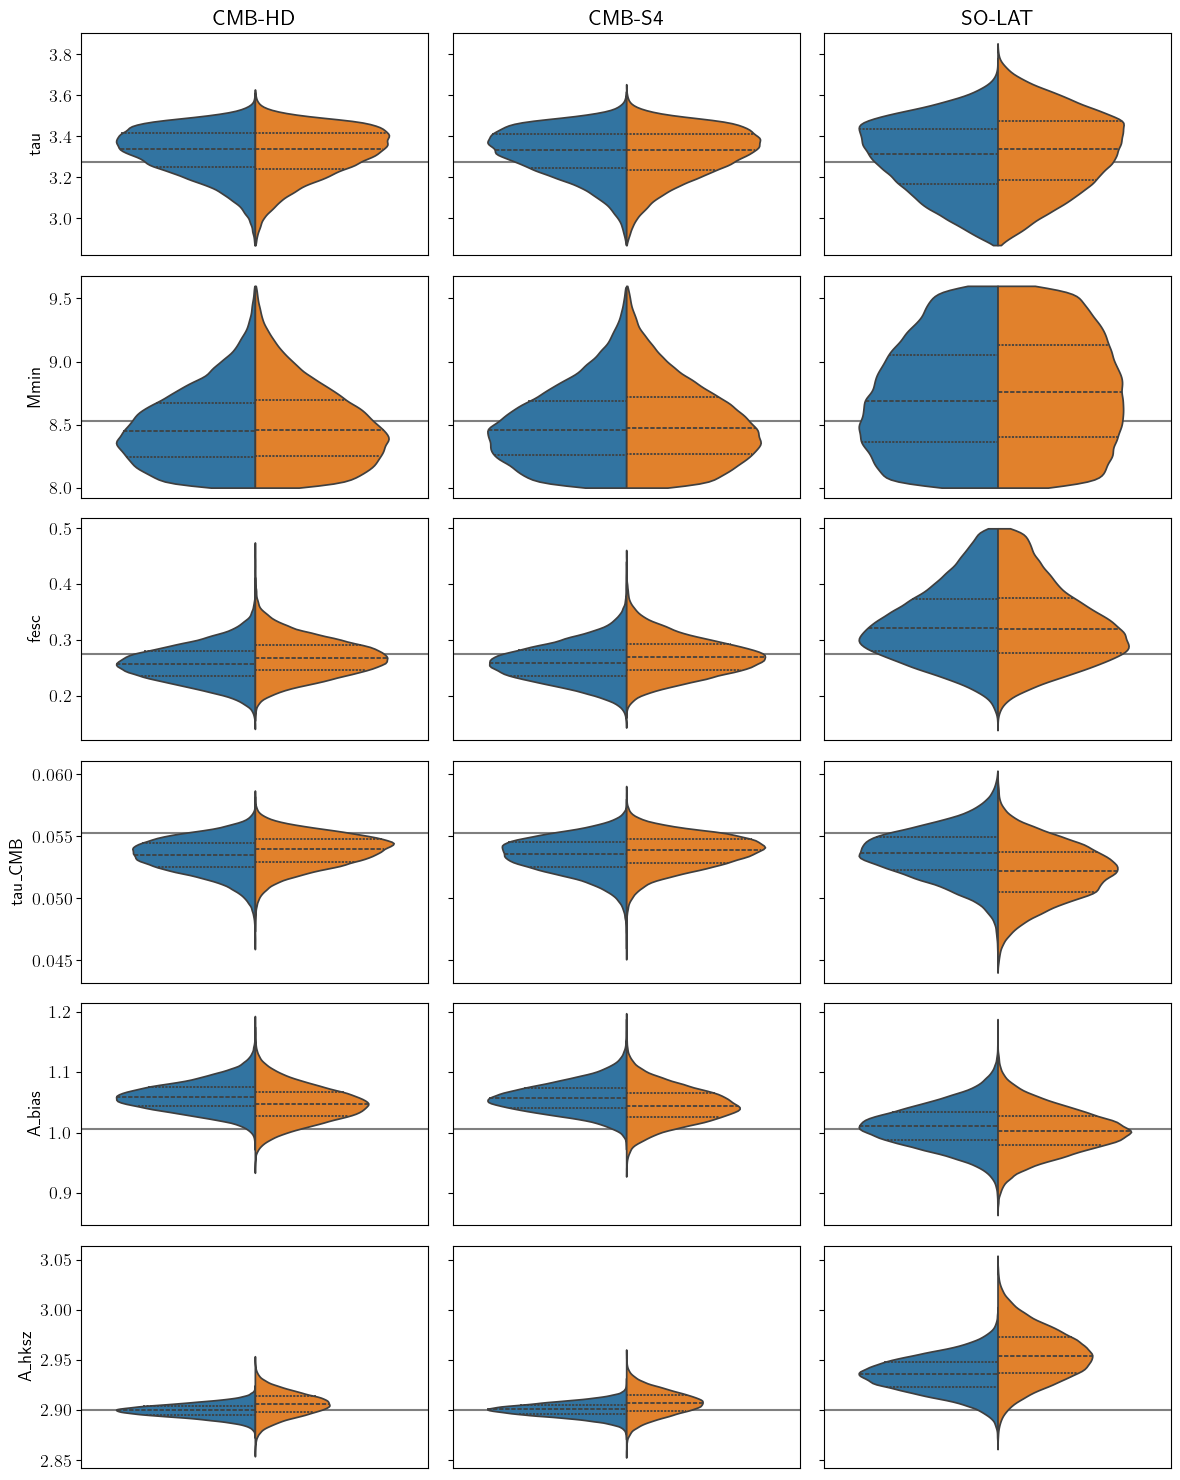

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(len(pnames), len(survey_labels), figsize=(12, 15), sharex=False, sharey='row')
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i_survey, survey in enumerate(survey_labels):
    for i_param, param in enumerate(dim_labels):
        print(f"{i_survey}, {survey}")
        print(f"{i_param}, {param}")

        ax = axs[i_param, i_survey]
        ax.axhline(list(true_values.values())[i_param], color='black', alpha=.5, zorder=0)
        # Filter to only the two main groups
        df_subset = df_samples[
            (df_samples["parameter"] == param) &
            (df_samples["rundir"].isin(rundirs)) &
            (df_samples["survey"] == survey) &
            (df_samples["setup"] == 'noiseless')].copy()
           # (df_samples["setup"].isin(setups[2:]))

    
        # Create a new column for combined group/subgroup label
        df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
        # Plot each group_subgroup as a separate category on the x-axis
        sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
                       inner='quart', hue="rundir", x="group_subgroup", y="value", ax=ax)
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_title(param)
        ax.get_legend().remove()

        if i_param == 0:
            xlabel = survey
        else:
            xlabel = None
            
        if i_survey == 0:
            ylabel = param
        else:
            ylabel = None

        ax.set_title(xlabel)
        ax.set_xlabel(None)
        ax.set_ylabel(ylabel)

# for i_param, param in enumerate(dim_labels):
#     print(f"{i_survey}, {survey}")
#     # print(f"{i_param}, {param}")

#     ax = axs[i_param, i_survey+1]
#     ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
#     # Filter to only the two main groups
#     df_subset = df_samples[
#         (df_samples["parameter"] == param) &
#         (df_samples["rundir"] == 'productionruns2_mechaemu') &
#         (df_samples["survey"] == 'CMB-HD') &
#         (df_samples["setup"].isin(['noiseless_priors', 'noiseless_Planck_priors']))
# #       (df_samples["setup"] == 'CMB-HD_priors')
#     ].copy()

#     # Create a new column for combined group/subgroup label
#     df_subset["group_subgroup"] = 'priors' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
    
#     # Plot each group_subgroup as a separate category on the x-axis
#     sns.violinplot(data=df_subset, hue="setup", split=True, common_norm=True, cut=0,
#                    inner='quart', x="group_subgroup", y="value", ax=ax)
#     ax.set_title(param)
#     ax.get_legend().remove()

plt.tight_layout()
# plt.savefig("violins.png", dpi=300, bbox_inches='tight')


## Appendix Plots

In [92]:
import os
import re

directory = f"{base_dir}/cuts"
pattern = re.compile(r".*\d{5}.*\.npz$")  # matches exact 5-digit numbers

fns = []
for filename in os.listdir(directory):
    if pattern.search(filename):
        fns.append(filename)

fns

['simu10539_cuts.npz',
 'simu10059_cuts.npz',
 'simu11933_cuts.npz',
 'simu14107_cuts.npz',
 'simu13646_cuts.npz',
 'simu15060_cuts.npz',
 'simu10528_cuts.npz',
 'simu12286_cuts.npz',
 'simu10835_cuts.npz',
 'simu10245_cuts.npz',
 'simu15042_cuts.npz',
 'simu12327_cuts.npz',
 'simu17099_cuts.npz',
 'simu10505_cuts.npz',
 'simu13873_cuts.npz',
 'simu11501_cuts.npz',
 'simu10324_cuts.npz',
 'simu12792_cuts.npz',
 'simu11174_cuts.npz',
 'simu12039_cuts.npz']

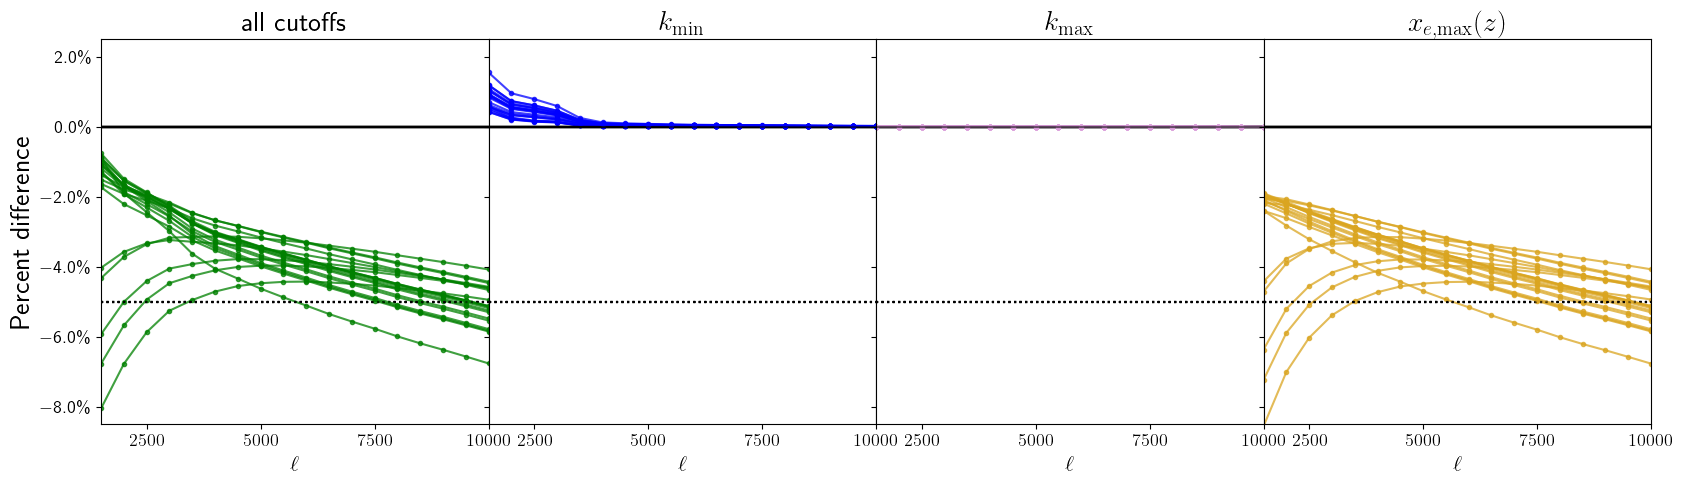

In [94]:
from matplotlib.ticker import PercentFormatter, LinearLocator, MultipleLocator

cuts = ['uncut',  'cut', 'kmin', 'kmax', 'xemax']
labels = ['all cutoffs', r'$k_{\mathrm{min}}$', r'$k_{\mathrm{max}}$', r'$x_{e,\mathrm{max}} (z)$']

fig, axes = plt.subplots(1,len(cuts[1:]), sharex=True, sharey=True, figsize=(20,5))
fig.subplots_adjust(wspace=0.0)

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)


    for i, ax in enumerate(axes):

        ax.plot(ells, (kSZ[cuts[i+1]] - kSZ['uncut']) / kSZ['uncut'], color=colors[i], alpha=.75, marker='.', label=fn)

        ax.axhline(0.0, color='black', alpha=.5)

        ax.axhline(-.1, color='black', alpha=.1, ls=":")
        ax.axhline(.1, color='black', alpha=.1, ls=":")

        ax.axhline(-.05, color='black', alpha=.25, ls=":")
        ax.axhline(.05, color='black', alpha=.25, ls=":")

        ax.axvline(1000, color='green')
        ax.axvline(1000, color='green')

        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_title(f"{labels[i]}", fontsize=20)
#plt.legend()
        ax.set_xlim(1500, 10000)
        ax.set_ylim(-.085,.025)
        ax.xaxis.set_major_locator(MultipleLocator(2500))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
axes[0].set_ylabel('Percent difference', fontsize=20)

fig.savefig('cuts.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

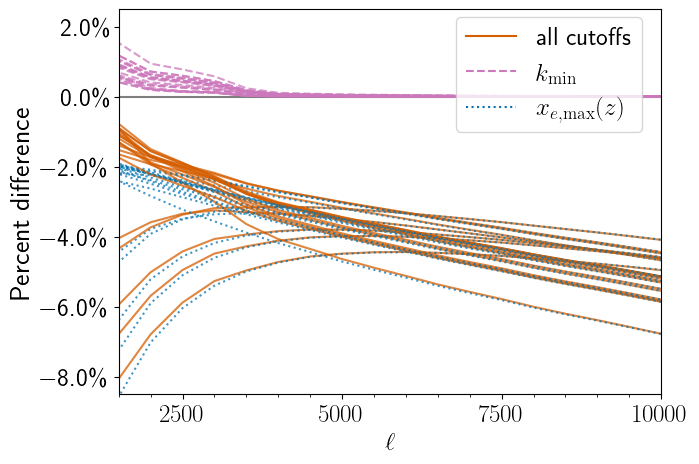

In [131]:
from matplotlib.ticker import PercentFormatter, LinearLocator, MultipleLocator

cuts = ['uncut',  'cut', 'kmin', 'xemax']
labels = ['all cutoffs', r'$k_{\mathrm{min}}$', r'$x_{e,\mathrm{max}} (z)$']

from matplotlib.lines import Line2D

linestyles = ['-', '--', ':']
cutcolors = ['#d55e00', '#cc78bc', '#0173b2'] #['#0173b2', '#de8f05', '#029e73']
legend_lines = []

for i in range(len(cuts[1:])):
    l = Line2D([0], [0], color=cutcolors[i], linestyle=linestyles[i], alpha=1.0, label=labels[i])
    legend_lines.append(l)

fig, ax = plt.subplots(figsize=(7,5))
fig.subplots_adjust(wspace=0.0)

ax.axhline(0.0, color='black', alpha=.5)


for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)

    for i, cut in enumerate(cuts[1:]):
        ax.plot(ells, (kSZ[cut] - kSZ['uncut']) / kSZ['uncut'],
                color=cutcolors[i], alpha=.75, ls=linestyles[i])


ax.set_xlabel(r'$\ell$', fontsize=18)

#plt.legend()
ax.set_xlim(1500, 10000)
ax.set_ylim(-.085,.025)
ax.xaxis.set_major_locator(MultipleLocator(2500))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
ax.tick_params(axis='both', which='major', labelsize=18)  # major ticks
ax.tick_params(axis='both', which='minor', labelsize=15)  # minor ticks


fig.legend(handles=legend_lines, loc='upper right', fontsize=18, bbox_to_anchor=(.89, .89))
        
ax.set_ylabel('Percent difference', fontsize=20)

fig.savefig('cuts.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
k_res[1]

2.7170531058073886

0.021226977389120223
cutoff at 0.022272727272727274 vs 1e-06
1.5
cutoff at 1.526315789473684 vs 10000.0
0.00416667
cutoff at 0.004166666666666667 vs 0.0


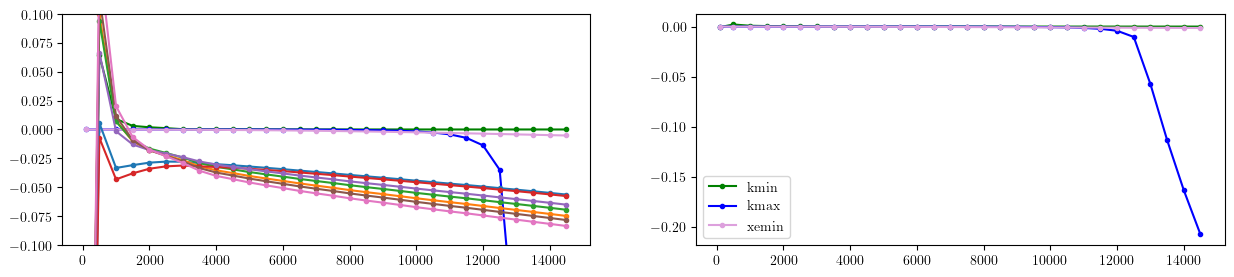

In [ ]:
cuts = [kmin_cuts, kmax_cuts, xemin_cuts, xemax_cuts]
vals = [k_res[0], 1.5, 0.00416667, .97]
lab = ['kmin', 'kmax', 'xemin', 'xemax']

fig, ax = plt.subplots(1,2, figsize=(15,3))

for i, c in enumerate(cuts[:-1]):
    Dells = c['Dells']
    cuts = c['cuts']

    print(vals[i])

    if i % 2 == 0:
        j = 0
    elif i % 2 == 1:
        j = -1

    index = np.argmin(np.abs(cuts - vals[i]))
    print(f"cutoff at {cuts[index]} vs {cuts[j]}")

    ax[0].plot(ells, ((Dells[index] - Dells[j]) / Dells[j]), label=lab[i], marker='.', color=colors[i])
    ax[1].plot(ells, (Dells[index] - Dells[j]), label=lab[i], marker='.', color=colors[i])

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)

    ax[0].plot(ells, (kSZ['cut'] - kSZ['uncut']) / kSZ['uncut'], marker='.')

#plt.xlim(500, 8000)
ax[0].set_ylim(-.1,.1)
plt.legend()

In [ ]:
k_res[0]

0.021226977389120223

In [ ]:
np.arange(ksz.find_zpiv(), 10.0, step=dz)

array([4.40909884, 4.55909884, 4.70909884, 4.85909884, 5.00909884,
       5.15909884, 5.30909884, 5.45909884, 5.60909884, 5.75909884,
       5.90909884, 6.05909884, 6.20909884, 6.35909884, 6.50909884,
       6.65909884, 6.80909884, 6.95909884, 7.10909884, 7.25909884,
       7.40909884, 7.55909884, 7.70909884, 7.85909884, 8.00909884,
       8.15909884, 8.30909884, 8.45909884, 8.60909884, 8.75909884,
       8.90909884, 9.05909884, 9.20909884, 9.35909884, 9.50909884,
       9.65909884, 9.80909884, 9.95909884])

In [ ]:
zpiv = ksz.find_zpiv()
z_pre =  np.logspace(np.log10(z_min), np.log10(zpiv),
    int((np.log10(zpiv) - np.log10(z_min)) / dlogz) + 1)

z_EOR = np.arange(zpiv + dz, 10.0, step=dz)
z_post = np.arange(10, z_max + 0.5, step=0.5)

z_integ = np.concatenate((z_pre, z_EOR, z_post))


In [ ]:
ksz.xe(ksz.find_zpiv()), ksz.xe_spline(ksz.find_zpiv()), ksz.find_zpiv()

here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0


(array(1.0510521), array(0.97), 4.409098837209303)

here
True
here2
1.0817405673349607


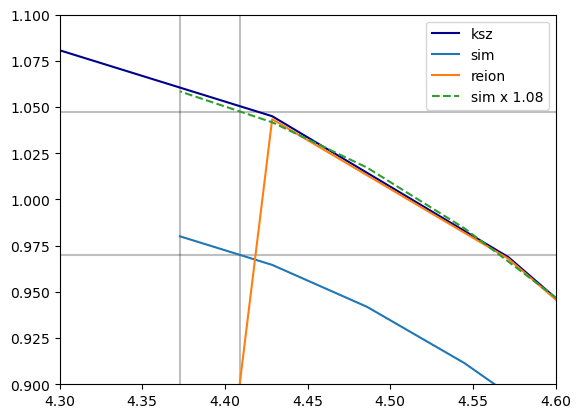

In [ ]:
plt.axvline(4.409098837209303, color='black', alpha=.25)
plt.axvline(sim.z.min(), color='black', alpha=.25)

plt.axhline(.97, color='black', alpha=.25)
plt.axhline(1.08 * .97, color='black', alpha=.25)

xe = ksz.xe(z)

plt.plot(z, xe, color='darkblue', label='ksz')
plt.plot(sim.z, sim.xe, label='sim')
plt.plot(z, ksz.xe_reion, label='reion')


plt.plot(sim.z, 1.08 * sim.xe, ls='--', label='sim x 1.08')




plt.xlim(4.3, 4.6)
plt.ylim(.9,1.1)
plt.legend()

In [ ]:
print('Redshifts are:')
print(z)
print()

print(f"Early ends at {ksz.z_data.max()}")
print(ksz.xe_early)
print()

print(f"Reion from {ksz.z_data.min()} to {ksz.z_data.max()}")
print(ksz.xe_reion)
print()

print(f"Late")
print(ksz.xe_late)
print()

print(ksz.xe_He)
print()

Redshifts are:
[ 3.          3.14285714  3.28571429  3.42857143  3.57142857  3.71428571
  3.85714286  4.          4.14285714  4.28571429  4.42857143  4.57142857
  4.71428571  4.85714286  5.          5.14285714  5.28571429  5.42857143
  5.57142857  5.71428571  5.85714286  6.          6.14285714  6.28571429
  6.42857143  6.57142857  6.71428571  6.85714286  7.          7.14285714
  7.28571429  7.42857143  7.57142857  7.71428571  7.85714286  8.
  8.14285714  8.28571429  8.42857143  8.57142857  8.71428571  8.85714286
  9.          9.14285714  9.28571429  9.42857143  9.57142857  9.71428571
  9.85714286 10.        ]

Early ends at 18.795
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

Reion from 4.3728 to 18.795
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         1.04344471 0.96794
 0.85784361 0.73712865 0.62617375 0.53079526 0.45014085

In [ ]:
ksz.find_zpiv()

here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0


4.409098837209303

In [ ]:
zpiv = ksz.find_zpiv()

1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.96459
late 0.0
He 0
1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.9673654384515687
late 0.0
He 0
1.0
early 0.0
reion 0.9697873139940252
late 0.0
He 0
1.0
early 0.0
reion 0.9699902002012757
late 0.0
He 0
1.0
early 0.0
reion 0.9699999603593609
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999925594
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999999999
late 0.0
He 0
1.0
early 0.0
reion 0.9700000000002778
late 0.0
He 0


In [ ]:
zpiv

4.409098837209303

In [ ]:
ksz.xe_spline(zpiv), ksz.xe(zpiv)

1.0817405673349607
early 0.0
reion 1.0492883503149117
late 0.0
He 0.0017637483296882278


(array(0.97), array(1.0510521))

In [ ]:
ksz.xe_early + ksz.xe_reion + ksz.xe_late + ksz.xe_He

np.float64(1.0510520986446)

In [ ]:
ksz.xe_early, ksz.xe_reion, ksz.xe_late, ksz.xe_He

(array(0.),
 np.float64(1.0492883503149117),
 array(0.),
 np.float64(0.0017637483296882278))

In [ ]:
.97 * 1.08 + ksz.xe_He

np.float64(1.0493637483296883)

In [ ]:
ksz.xe(30)

1.0817405673349607
early 0.0001
reion 0.0
late 0.0
He 0.0


array(0.0001)

In [ ]:
z = np.linspace(3,10)



here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607


array(1.0510521)